In [ ]:
import zipfile

# replace archive.zip with your exact file name if different
zip_path = "/content/archive.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/")

print("✅ Unzipped successfully!")


OSError: [Errno 22] Invalid argument

In [ ]:
import os
os.listdir("/content")


['.config', 'EuroSAT_RGB', 'archive.zip', 'sample_data']

In [ ]:
import pathlib
data_dir = pathlib.Path("/content/EuroSAT_RGB/2750")


In [ ]:
import pathlib, os
# UPDATE this if the folder found by previous cell is different.
data_dir = pathlib.Path("/content/EuroSAT_RGB/2750")

assert data_dir.exists(), f"Dataset folder not found: {data_dir}. Check Colab file browser and update path."
print("Using data directory:", data_dir)
print("Class subfolders (first 20):", os.listdir(data_dir)[:20])


AssertionError: Dataset folder not found: /content/EuroSAT_RGB/2750. Check Colab file browser and update path.

In [ ]:
import tensorflow as tf
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print("Class dictionary (index -> name):")
for i, name in enumerate(train_ds.class_names):
    print(i, ":", name)

# Prefetch for speed
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
num_classes = len(train_ds.class_names)
print("Number of classes:", num_classes)


NotFoundError: Could not find directory /content/EuroSAT_RGB/2750

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

def plot_history(history, title):
    plt.figure()
    plt.plot(history.history['accuracy'], label='train_acc')
    plt.plot(history.history['val_accuracy'], label='val_acc')
    plt.title(title + " accuracy")
    plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.legend(); plt.grid(True); plt.show()

def eval_and_report(model, val_ds, class_names):
    val_loss, val_acc = model.evaluate(val_ds, verbose=0)
    print(f"Validation accuracy: {val_acc*100:.2f}%")
    # quick confusion (small)
    y_true = []
    y_pred = []
    for x,y in val_ds:
        preds = model.predict(x, verbose=0)
        y_true.extend(y.numpy().tolist())
        y_pred.extend(np.argmax(preds, axis=1).tolist())
    from sklearn.metrics import classification_report, confusion_matrix
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=3))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    plt.imshow(cm, interpolation='nearest')
    plt.title("Confusion matrix")
    plt.colorbar()
    ticks = np.arange(len(class_names))
    plt.xticks(ticks, class_names, rotation=45, ha='right')
    plt.yticks(ticks, class_names)
    plt.tight_layout(); plt.show()


In [ ]:
# ResNet50 quick run (frozen backbone)
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input

base = ResNet50(include_top=False, weights="imagenet", input_shape=IMG_SIZE+(3,))
base.trainable = False

inputs = keras.Input(shape=IMG_SIZE + (3,))
x = layers.Rescaling(1./255)(inputs)
x = preprocess_input(x)  # normalizes for ResNet
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)
model_resnet = keras.Model(inputs, outputs, name="ResNet50_quick")

model_resnet.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_resnet.summary()

hist_r = model_resnet.fit(train_ds, validation_data=val_ds, epochs=5)
plot_history(hist_r, "ResNet50_quick")
eval_and_report(model_resnet, val_ds, train_ds.class_names)

# save quick
model_resnet.save("ResNet50_quick.keras")
print("Saved ResNet50_quick.keras")


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


NameError: name 'num_classes' is not defined

In [ ]:
from tensorflow.keras.applications import EfficientNetB0, preprocess_input as eff_preprocess

base2 = EfficientNetB0(include_top=False, weights="imagenet", input_shape=IMG_SIZE+(3,))
base2.trainable = False

inputs = keras.Input(shape=IMG_SIZE + (3,))
x = layers.Rescaling(1./255)(inputs)
x = eff_preprocess(x)
x = base2(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)
model_eff = keras.Model(inputs, outputs, name="EfficientNetB0_quick")

model_eff.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_eff.summary()

hist_e = model_eff.fit(train_ds, validation_data=val_ds, epochs=5)
plot_history(hist_e, "EfficientNetB0_quick")
eval_and_report(model_eff, val_ds, train_ds.class_names)

model_eff.save("EfficientNetB0_quick.keras")
print("Saved EfficientNetB0_quick.keras")


ImportError: cannot import name 'preprocess_input' from 'tensorflow.keras.applications' (/usr/local/lib/python3.12/dist-packages/keras/_tf_keras/keras/applications/__init__.py)

In [ ]:
# Quick bar chart of results
resnet_acc = model_resnet.evaluate(val_ds, verbose=0)[1]
eff_acc = model_eff.evaluate(val_ds, verbose=0)[1]

import matplotlib.pyplot as plt
names = ["ResNet50_quick", "EfficientNetB0_quick"]
accs = [resnet_acc*100, eff_acc*100]
plt.figure(figsize=(6,3))
plt.bar(names, accs)
plt.ylim(0,100)
plt.ylabel("Validation Accuracy (%)")
plt.title("Quick model comparison")
for i,v in enumerate(accs):
    plt.text(i, v+1, f"{v:.2f}%", ha='center')
plt.show()


NameError: name 'model_resnet' is not defined

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving LULC_India_Full_2021_200m.tif to LULC_India_Full_2021_200m (1).tif


In [ ]:
import rasterio
import numpy as np
import pandas as pd

lulc_path = "/content/LULC_India_Full_2021_200m.tif"
class_areas = {}

with rasterio.open(lulc_path) as src:
    block_size = 2048  # tile size to keep RAM low
    for ji, window in src.block_windows(1):
        data = src.read(1, window=window)
        unique, counts = np.unique(data, return_counts=True)
        for u, c in zip(unique, counts):
            class_areas[u] = class_areas.get(u, 0) + c * (src.res[0] * src.res[1]) / 1e6  # km²

df = pd.DataFrame(list(class_areas.items()), columns=['LULC_Class', 'Area_km2'])
df.to_csv('/content/LULC_Area_Summary.csv', index=False)
print("✅ Saved: LULC_Area_Summary.csv")

✅ Saved: LULC_Area_Summary.csv


In [ ]:
import rasterio
from rasterio.mask import mask
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import box

lulc_path = "/content/LULC_India_Full_2021_200m.tif"
north_bbox = box(68, 23, 97.5, 37)   # approx. north India
south_bbox = box(68, 6, 97.5, 23)    # approx. south India

def area_summary(bounds, label):
    with rasterio.open(lulc_path) as src:
        out_image, _ = mask(src, [bounds], crop=True)
        data = out_image[0]
        unique, counts = np.unique(data, return_counts=True)
        area = (src.res[0]*src.res[1])/1e6
        df = pd.DataFrame({'LULC_Class': unique, 'Area_km2': counts*area})
        df.to_csv(f"/content/LULC_Area_{label}.csv", index=False)
        print(f"✅ Saved: /content/LULC_Area_{label}.csv")

area_summary(north_bbox, "North")
area_summary(south_bbox, "South")


✅ Saved: /content/LULC_Area_North.csv
✅ Saved: /content/LULC_Area_South.csv


✅ File loaded successfully!
Raster shape: (16009, 16272)
CRS: EPSG:4326
Bounds: BoundingBox(left=68.16139386858606, bottom=6.752072087994101, right=97.39616647497176, top=35.51433085493294)

⏳ Counting LULC pixels tile by tile...


100%|██████████| 16/16 [00:07<00:00,  2.27it/s]



✅ Counting completed!

📊 Land Cover Area Summary (km²):
Unknown(0)                        6,966,206.44
Tree cover                          929,931.00
Grassland                           348,965.08
Cropland                          1,674,876.72
Built-up                             68,056.48
Bare / Sparse vegetation            177,348.80
Snow & Ice                           26,106.92
Permanent water bodies               63,137.56
Moss & lichen                        14,976.88
Herbaceous wetland                    5,232.48
Shrubland                           141,243.12
Mangroves                             3,856.44

✅ CSV saved: /content/LULC_Area_Summary_India_200m.csv


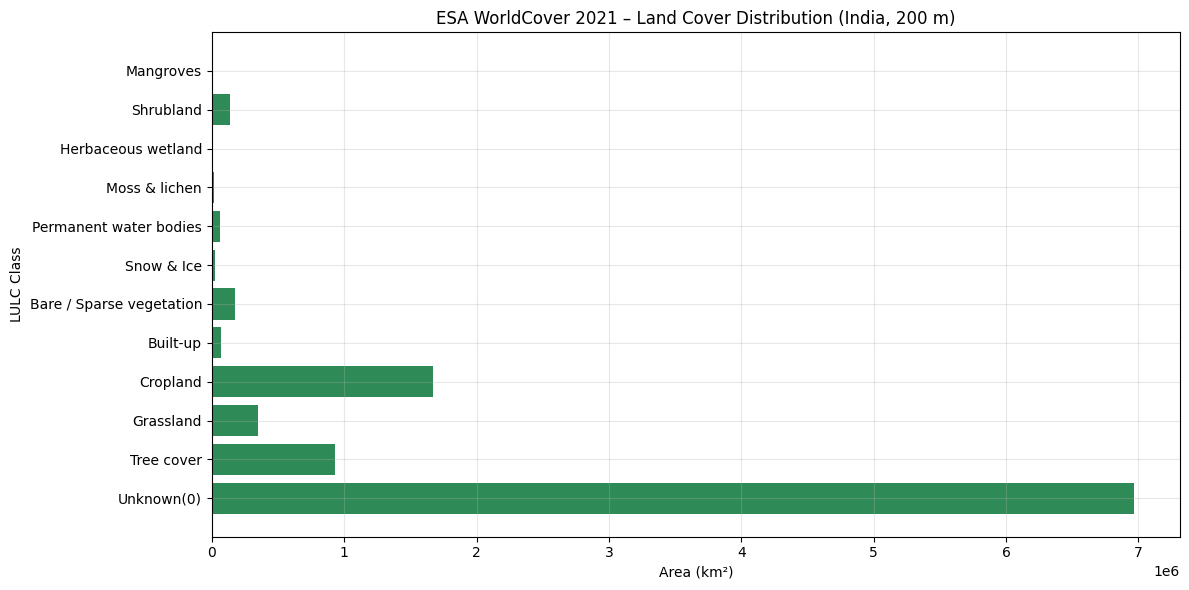

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================
# 🌍 ESA WorldCover 2021 – INDIA (200 m)
# SAFE + RAM-EFFICIENT CODE (TILE BASED)
# ============================================

# STEP 1️⃣ – Install dependencies (run once)
!pip install rasterio geopandas matplotlib pandas numpy tqdm

# STEP 2️⃣ – Import libraries
import rasterio
from rasterio.windows import Window
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

# STEP 3️⃣ – Set file path to your uploaded GeoTIFF
# (you already have this file in Colab or Google Drive)
lulc_path = '/content/LULC_India_Full_2021_200m.tif'  # 👈 update if stored in Drive

# STEP 4️⃣ – Open raster safely
dataset = rasterio.open(lulc_path)
print("✅ File loaded successfully!")
print("Raster shape:", (dataset.height, dataset.width))
print("CRS:", dataset.crs)
print("Bounds:", dataset.bounds)

# STEP 5️⃣ – Class dictionary (ESA WorldCover 2021)
classes = {
    10: "Tree cover",
    20: "Shrubland",
    30: "Grassland",
    40: "Cropland",
    50: "Built-up",
    60: "Bare / Sparse vegetation",
    70: "Snow & Ice",
    80: "Permanent water bodies",
    90: "Herbaceous wetland",
    95: "Mangroves",
    100: "Moss & lichen"
}

# STEP 6️⃣ – Process the raster in small tiles to avoid memory crash
tile_size = 1024  # pixels per tile
height, width = dataset.height, dataset.width
counts = {}

print("\n⏳ Counting LULC pixels tile by tile...")
for row in tqdm(range(0, height, tile_size)):
    for col in range(0, width, tile_size):
        w = Window(col, row,
                   min(tile_size, width - col),
                   min(tile_size, height - row))
        arr = dataset.read(1, window=w)
        unique, c = np.unique(arr, return_counts=True)
        for u, cnt in zip(unique, c):
            counts[u] = counts.get(u, 0) + cnt

dataset.close()
print("\n✅ Counting completed!")

# STEP 7️⃣ – Convert pixel counts to area (km²)
pixel_area_km2 = (0.2 * 0.2)  # 200 m × 200 m = 0.04 km² per pixel
area_stats = {
    classes.get(k, f"Unknown({k})"): round(v * pixel_area_km2, 2)
    for k, v in counts.items()
}

# STEP 8️⃣ – Display results
print("\n📊 Land Cover Area Summary (km²):")
for k, v in area_stats.items():
    print(f"{k:<30} {v:>15,.2f}")

# STEP 9️⃣ – Convert to DataFrame & Save CSV
df = pd.DataFrame(list(area_stats.items()), columns=['LULC_Class', 'Area_km2'])
csv_path = '/content/LULC_Area_Summary_India_200m.csv'
df.to_csv(csv_path, index=False)
print(f"\n✅ CSV saved: {csv_path}")

# STEP 🔟 – Plot chart
plt.figure(figsize=(12,6))
plt.barh(df['LULC_Class'], df['Area_km2'], color='seagreen')
plt.xlabel("Area (km²)")
plt.ylabel("LULC Class")
plt.title("ESA WorldCover 2021 – Land Cover Distribution (India, 200 m)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# STEP 1️⃣1️⃣ – Download CSV directly from Colab
from google.colab import files
files.download(csv_path)

In [ ]:
with rasterio.open('/content/LULC_India_Full_2021_200m.tif') as src:
    print("NoData value:", src.nodata)


NoData value: None


✅ File loaded successfully!
Raster shape: (16009, 16272)
CRS: EPSG:4326
Bounds: BoundingBox(left=68.16139386858606, bottom=6.752072087994101, right=97.39616647497176, top=35.51433085493294)

🧹 Removed 174,155,161 background pixels

📊 Land Cover Area (km²):
Tree cover: 929,931.0
Shrubland: 141,243.12
Grassland: 348,965.08
Cropland: 1,674,876.72
Built-up: 68,056.48
Bare / Sparse vegetation: 177,348.8
Snow & Ice: 26,106.92
Permanent water bodies: 63,137.56
Herbaceous wetland: 5,232.48
Mangroves: 3,856.44
Moss & lichen: 14,976.88


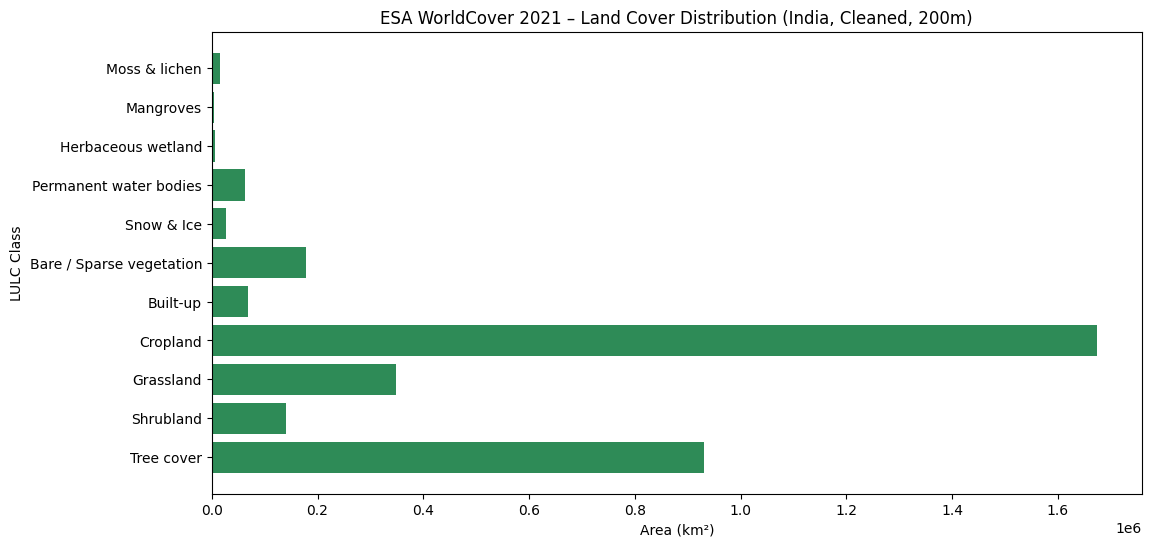


✅ CSV summary saved as: LULC_Area_Summary_Cleaned.csv


In [ ]:
# ============================================
# 🌍 ESA WorldCover 2021 – LULC Analysis (India, Cleaned)
# ============================================

# STEP 1️⃣ – Install dependencies (if not already installed)
!pip install rasterio geopandas matplotlib pandas numpy

# STEP 2️⃣ – Import libraries
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# STEP 3️⃣ – Load the GeoTIFF (uploaded to Colab)
lulc_path = '/content/LULC_India_Full_2021_200m.tif'  # 👈 Update if path differs

# STEP 4️⃣ – Open the raster
dataset = rasterio.open(lulc_path)
lulc = dataset.read(1)

print("✅ File loaded successfully!")
print("Raster shape:", lulc.shape)
print("CRS:", dataset.crs)
print("Bounds:", dataset.bounds)

# STEP 5️⃣ – Remove invalid background pixels (value = 0)
lulc_clean = lulc[lulc != 0]
print(f"\n🧹 Removed {np.sum(lulc == 0):,} background pixels")

# STEP 6️⃣ – ESA WorldCover class definitions
classes = {
    10: "Tree cover",
    20: "Shrubland",
    30: "Grassland",
    40: "Cropland",
    50: "Built-up",
    60: "Bare / Sparse vegetation",
    70: "Snow & Ice",
    80: "Permanent water bodies",
    90: "Herbaceous wetland",
    95: "Mangroves",
    100: "Moss & lichen"
}

# STEP 7️⃣ – Compute area (200 m pixel → 0.04 km²)
pixel_area_km2 = 0.04
unique, counts = np.unique(lulc_clean, return_counts=True)
area_stats = {classes.get(u, f"Unknown({u})"): round(c * pixel_area_km2, 2)
              for u, c in zip(unique, counts)}

print("\n📊 Land Cover Area (km²):")
for k, v in area_stats.items():
    print(f"{k}: {v:,}")

# STEP 8️⃣ – Plot cleaned chart
plt.figure(figsize=(12, 6))
plt.barh(list(area_stats.keys()), list(area_stats.values()), color='seagreen')
plt.xlabel("Area (km²)")
plt.ylabel("LULC Class")
plt.title("ESA WorldCover 2021 – Land Cover Distribution (India, Cleaned, 200m)")
plt.show()

# STEP 9️⃣ – Save CSV summary
df = pd.DataFrame(list(area_stats.items()), columns=['LULC_Class', 'Area_km²'])
df.to_csv('/content/LULC_Area_Summary_Cleaned.csv', index=False)
print("\n✅ CSV summary saved as: LULC_Area_Summary_Cleaned.csv")


In [ ]:
# ============================================
# 🌍 Sentinel-2 + ESA WorldCover (Karnataka)
# ML Land Cover Classification & Accuracy Analysis
# ============================================

# STEP 1️⃣ – Install required libraries
!pip install rasterio geopandas matplotlib pandas numpy scikit-learn

# STEP 2️⃣ – Import modules
import rasterio
from rasterio.merge import merge
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# STEP 3️⃣ – Define file paths
lulc_path = "/content/WorldCover_Karnataka_2021.tif"

# All 5 Sentinel-2 tiles
sentinel_paths = [
    "/content/Sentinel2_Karnataka_2021.tif",
    "/content/Sentinel2_Karnataka_2021-0000000000-0000000000.tif",
    "/content/Sentinel2_Karnataka_2021-0000000000-0000011776.tif",
    "/content/Sentinel2_Karnataka_2021-0000011776-0000000000.tif",
    "/content/Sentinel2_Karnataka_2021-0000011776-0000011776.tif"
]

# STEP 4️⃣ – Merge Sentinel-2 tiles
datasets = [rasterio.open(p) for p in sentinel_paths]
mosaic, out_transform = merge(datasets)
mosaic = mosaic.astype("float32")
profile = datasets[0].profile
profile.update(height=mosaic.shape[1], width=mosaic.shape[2], transform=out_transform)

for ds in datasets:
    ds.close()

print("✅ Sentinel-2 tiles merged successfully!")
print("Mosaic shape:", mosaic.shape)  # (bands, rows, cols)

# STEP 5️⃣ – Load LULC map
with rasterio.open(lulc_path) as lulc_src:
    lulc = lulc_src.read(1)
print("✅ LULC map loaded successfully!")

# STEP 6️⃣ – Match dimensions
min_rows = min(mosaic.shape[1], lulc.shape[0])
min_cols = min(mosaic.shape[2], lulc.shape[1])
mosaic = mosaic[:, :min_rows, :min_cols]
lulc = lulc[:min_rows, :min_cols]

# STEP 7️⃣ – Prepare features (X) and labels (y)
X = mosaic.reshape(mosaic.shape[0], -1).T
y = lulc.flatten()

# Remove invalid background pixels (0)
mask = y > 0
X = X[mask]
y = y[mask]

print(f"✅ Prepared data with {X.shape[0]:,} samples and {X.shape[1]} features")

# Optional: sample to speed up (use 5% pixels if Colab RAM is low)
sample_size = int(0.05 * X.shape[0])
idx = np.random.choice(X.shape[0], sample_size, replace=False)
X, y = X[idx], y[idx]

# STEP 8️⃣ – Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# STEP 9️⃣ – Train multiple models
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "SVM": SVC(kernel='rbf', gamma='scale'),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

results = {}

for name, model in models.items():
    print(f"\n🔹 Training {name} ...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"✅ {name} Accuracy: {round(acc * 100, 2)}%")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))

# STEP 🔟 – Plot model comparison
plt.figure(figsize=(7, 5))
plt.bar(results.keys(), [v * 100 for v in results.values()], color=['green', 'orange', 'blue'])
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison – Karnataka Land Cover Classification")
plt.show()

# STEP 1️⃣1️⃣ – Save results
pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"]).to_csv("/content/Karnataka_Model_Accuracy.csv", index=False)
print("\n✅ Accuracy results saved as: Karnataka_Model_Accuracy.csv")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 84.4 MB/s eta 0:00:00


In [ ]:
# =========================================
# 🌍 Land Cover Classification – Karnataka (Fast Version)
# =========================================

!pip install rasterio numpy pandas scikit-learn matplotlib

import rasterio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ===== 1️⃣ Paths =====
lulc_path = "/content/WorldCover_Karnataka_2021.tif"
sentinel_paths = [
    "/content/Sentinel2_Karnataka_2021-0000000000-0000000000.tif",
    "/content/Sentinel2_Karnataka_2021-0000000000-0000011776.tif",
    "/content/Sentinel2_Karnataka_2021-0000011776-0000000000.tif",
    "/content/Sentinel2_Karnataka_2021-0000011776-0000011776.tif",
    "/content/Sentinel2_Karnataka_2021.tif"
]

# ===== 2️⃣ Merge and sample bands =====
def read_and_stack(paths):
    arrs = []
    for p in paths:
        with rasterio.open(p) as src:
            arrs.append(src.read([2,3,4,8]))  # Blue, Green, Red, NIR
    return np.concatenate(arrs, axis=2)

print("📥 Reading Sentinel-2 data (this takes ~3–5 min)...")
stack = read_and_stack(sentinel_paths)
print("Shape of stack:", stack.shape)

# ===== 3️⃣ Read LULC labels =====
with rasterio.open(lulc_path) as src:
    lulc = src.read(1)

# ===== 4️⃣ Sample smaller portion =====
mask = lulc > 0
X = stack[:, :, :][mask]
y = lulc[mask]

sample_size = int(0.01 * X.shape[0])  # 1% sampling
idx = np.random.choice(np.arange(X.shape[0]), sample_size, replace=False)
X_sample, y_sample = X[idx], y[idx]

print(f"Using {sample_size:,} pixels for training/testing")

# ===== 5️⃣ Train/Test split =====
X_train, X_test, y_train, y_test = train_test_split(X_sample, y_sample, test_size=0.3, random_state=42)

# ===== 6️⃣ Random Forest Model =====
rf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

# ===== 7️⃣ Accuracy =====
acc = accuracy_score(y_test, y_pred)
print(f"\n✅ Model Accuracy: {acc*100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# ===== 8️⃣ Plot Accuracy =====
plt.figure(figsize=(6,4))
plt.bar(["Random Forest"], [acc*100], color="seagreen")
plt.title("Model Accuracy (%)")
plt.ylabel("Accuracy")
plt.ylim(0, 100)
plt.show()

# ===== 9️⃣ Save accuracy =====
pd.DataFrame({"Model":["Random Forest"], "Accuracy":[acc*100]}).to_csv("/content/Karnataka_Model_Accuracy.csv", index=False)
print("✅ Saved: Karnataka_Model_Accuracy.csv")


📥 Reading Sentinel-2 data (this takes ~3–5 min)...


IndexError: band index 8 out of range (not in (1, 2, 3, 4))

In [ ]:
# =========================================
# 🌍 Land Cover Classification – Karnataka (Fixed Version for 4-band TIFFs)
# =========================================

!pip install rasterio numpy pandas scikit-learn matplotlib

import rasterio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ===== 1️⃣ Paths =====
lulc_path = "/content/WorldCover_Karnataka_2021.tif"
sentinel_paths = [
    "/content/Sentinel2_Karnataka_2021-0000000000-0000000000.tif",
    "/content/Sentinel2_Karnataka_2021-0000000000-0000011776.tif",
    "/content/Sentinel2_Karnataka_2021-0000011776-0000000000.tif",
    "/content/Sentinel2_Karnataka_2021-0000011776-0000011776.tif",
    "/content/Sentinel2_Karnataka_2021.tif"
]

# ===== 2️⃣ Merge and stack bands =====
def read_and_stack(paths):
    arrs = []
    for p in paths:
        with rasterio.open(p) as src:
            arrs.append(src.read())  # read all available bands (1–4)
    return np.concatenate(arrs, axis=2)

print("📥 Reading Sentinel-2 data (this takes ~2–4 min)...")
stack = read_and_stack(sentinel_paths)
print("✅ Shape of stacked array:", stack.shape)

# ===== 3️⃣ Read LULC labels =====
with rasterio.open(lulc_path) as src:
    lulc = src.read(1)

# ===== 4️⃣ Sample smaller portion to prevent crash =====
mask = lulc > 0
X = stack.reshape(-1, stack.shape[0])  # flatten
y = lulc.flatten()
mask = y > 0

X = X[mask]
y = y[mask]

# Reduce sample size for stability
sample_size = int(0.005 * X.shape[0])  # 0.5% of data
idx = np.random.choice(np.arange(X.shape[0]), sample_size, replace=False)
X_sample, y_sample = X[idx], y[idx]

print(f"✅ Using {sample_size:,} pixels for training/testing")

# ===== 5️⃣ Split data =====
X_train, X_test, y_train, y_test = train_test_split(X_sample, y_sample, test_size=0.3, random_state=42)

# ===== 6️⃣ Train Random Forest =====
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

# ===== 7️⃣ Accuracy =====
acc = accuracy_score(y_test, y_pred)
print(f"\n✅ Model Accuracy: {acc*100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# ===== 8️⃣ Plot Accuracy =====
plt.figure(figsize=(6,4))
plt.bar(["Random Forest"], [acc*100], color="seagreen")
plt.title("Model Accuracy (%)")
plt.ylabel("Accuracy")
plt.ylim(0, 100)
plt.show()

# ===== 9️⃣ Save accuracy =====
pd.DataFrame({"Model":["Random Forest"], "Accuracy":[acc*100]}).to_csv("/content/Karnataka_Model_Accuracy.csv", index=False)
print("✅ Saved: Karnataka_Model_Accuracy.csv")


📥 Reading Sentinel-2 data (this takes ~2–4 min)...


ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 11776 and the array at index 2 has size 4233

In [ ]:
!pip install rasterio numpy pandas scikit-learn matplotlib

import rasterio
from rasterio.merge import merge
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ====== 1️⃣ Paths ======
lulc_path = "/content/WorldCover_Karnataka_2021.tif"
sentinel_paths = [
    "/content/Sentinel2_Karnataka_2021-0000000000-0000000000.tif",
    "/content/Sentinel2_Karnataka_2021-0000000000-0000011776.tif",
    "/content/Sentinel2_Karnataka_2021-0000011776-0000000000.tif",
    "/content/Sentinel2_Karnataka_2021-0000011776-0000011776.tif"
]

# ====== 2️⃣ Merge Sentinel-2 tiles ======
src_files_to_mosaic = [rasterio.open(p) for p in sentinel_paths]
mosaic, out_trans = merge(src_files_to_mosaic)
for src in src_files_to_mosaic:
    src.close()

print("✅ Merged Sentinel-2 shape:", mosaic.shape)  # (bands, rows, cols)

# ====== 3️⃣ Load LULC ======
with rasterio.open(lulc_path) as src:
    lulc = src.read(1)

# ====== 4️⃣ Match extent (crop to smallest area)
rows = min(mosaic.shape[1], lulc.shape[0])
cols = min(mosaic.shape[2], lulc.shape[1])
mosaic = mosaic[:, :rows, :cols]
lulc = lulc[:rows, :cols]

print("✅ Matched data shape:", mosaic.shape, lulc.shape)

# ====== 5️⃣ Flatten for ML ======
mask = lulc > 0
X = mosaic[:, mask].T
y = lulc[mask]

# Reduce data for memory
sample_size = int(0.003 * X.shape[0])
idx = np.random.choice(np.arange(X.shape[0]), sample_size, replace=False)
X_sample, y_sample = X[idx], y[idx]

print(f"✅ Using {sample_size:,} pixels for training/testing")

# ====== 6️⃣ Train/Test Split ======
X_train, X_test, y_train, y_test = train_test_split(X_sample, y_sample, test_size=0.3, random_state=42)

# ====== 7️⃣ Random Forest ======
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

# ====== 8️⃣ Accuracy ======
acc = accuracy_score(y_test, y_pred)
print(f"\n✅ Model Accuracy: {acc*100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# ====== 9️⃣ Plot ======
plt.figure(figsize=(6,4))
plt.bar(["Random Forest"], [acc*100], color="seagreen")
plt.ylabel("Accuracy (%)")
plt.title("Karnataka Land Cover Model Accuracy")
plt.show()

# ====== 🔟 Save Results ======
pd.DataFrame({"Model":["Random Forest"], "Accuracy":[acc*100]}).to_csv("/content/Karnataka_Model_Accuracy.csv", index=False)
print("✅ Saved results as: Karnataka_Model_Accuracy.csv")


In [ ]:
import rasterio, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- Your uploaded files ---
lulc_path = "/content/WorldCover_Karnataka_2021.tif"

sentinel_paths = [
    "/content/Sentinel2_Karnataka_2021-0000000000-0000000000.tif",
    "/content/Sentinel2_Karnataka_2021-0000000000-0000011776.tif",
    "/content/Sentinel2_Karnataka_2021-0000011776-0000000000.tif",
    "/content/Sentinel2_Karnataka_2021-0000011776-0000011776.tif",
    "/content/Sentinel2_Karnataka_2021.tif"
]
print("✅ Paths ready")


✅ Paths ready


In [ ]:
def extract_samples(tile_path, lulc_path, sample_fraction=0.001):
    with rasterio.open(tile_path) as s2, rasterio.open(lulc_path) as lulc_ds:
        s2_arr = s2.read()                     # (bands, rows, cols)
        lulc_arr = lulc_ds.read(1)
        # Match shapes
        rows = min(s2_arr.shape[1], lulc_arr.shape[0])
        cols = min(s2_arr.shape[2], lulc_arr.shape[1])
        s2_arr, lulc_arr = s2_arr[:, :rows, :cols], lulc_arr[:rows, :cols]
        mask = lulc_arr > 0
        X = s2_arr[:, mask].T
        y = lulc_arr[mask]
        n = int(sample_fraction * X.shape[0])
        idx = np.random.choice(np.arange(X.shape[0]), n, replace=False)
        return X[idx], y[idx]

# Collect small random samples from each tile
X_all, y_all = [], []
for p in sentinel_paths:
    try:
        Xp, yp = extract_samples(p, lulc_path, 0.001)   # 0.1% pixels
        X_all.append(Xp)
        y_all.append(yp)
        print(f"✅ Sampled {Xp.shape[0]} pixels from {p.split('/')[-1]}")
    except Exception as e:
        print(f"⚠️ Skipped {p}: {e}")

# Merge all samples
X = np.vstack(X_all)
y = np.hstack(y_all)
print("✅ Combined dataset:", X.shape, "samples")


In [ ]:
# ============================================
# 🌍 ESA WorldCover + Sentinel-2 ML Classification (Karnataka)
# ============================================

# STEP 1️⃣ – Install dependencies
!pip install rasterio geopandas matplotlib pandas numpy scikit-learn xgboost tqdm --quiet

# STEP 2️⃣ – Import libraries
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from tqdm import tqdm

# STEP 3️⃣ – Define file paths
lulc_path = "/content/WorldCover_Karnataka_2021.tif"

sentinel_paths = [
    "/content/Sentinel2_Karnataka_2021-0000000000-0000000000.tif",
    "/content/Sentinel2_Karnataka_2021-0000000000-0000011776.tif",
    "/content/Sentinel2_Karnataka_2021-0000011776-0000000000.tif",
    "/content/Sentinel2_Karnataka_2021-0000011776-0000011776.tif",

]

# STEP 4️⃣ – Function to safely read Sentinel tiles
def read_tile(tile_path):
    with rasterio.open(tile_path) as src:
        arr = src.read().astype("float32")  # read all bands
    return arr

# STEP 5️⃣ – Read LULC (labels)
with rasterio.open(lulc_path) as src:
    lulc = src.read(1).astype("int16")
    lulc_bounds = src.bounds
    lulc_crs = src.crs
print("✅ LULC loaded:", lulc.shape)

# STEP 6️⃣ – Prepare training data from each Sentinel tile
X_all, y_all = [], []

for path in tqdm(sentinel_paths, desc="Processing Sentinel Tiles"):
    try:
        with rasterio.open(path) as src:
            sentinel = src.read().astype("float32")
            # Ensure same shape overlap
            rows, cols = min(sentinel.shape[1], lulc.shape[0]), min(sentinel.shape[2], lulc.shape[1])
            X = sentinel[:, :rows, :cols].reshape(sentinel.shape[0], -1).T
            y = lulc[:rows, :cols].reshape(-1)
            mask = y > 0
            X_all.append(X[mask])
            y_all.append(y[mask])
    except Exception as e:
        print(f"⚠️ Skipped {path}: {e}")

# Merge all samples
X = np.vstack(X_all)
y = np.hstack(y_all)
print("✅ Combined dataset:", X.shape, "samples")

# STEP 7️⃣ – Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# STEP 8️⃣ – Train multiple models
models = {
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel="rbf", gamma="scale"),
    "XGBoost": XGBClassifier(
        n_estimators=100, max_depth=8, learning_rate=0.1, subsample=0.8,
        tree_method="hist", objective="multi:softmax", num_class=len(np.unique(y))
    )
}

results = {}
for name, model in models.items():
    print(f"\n🚀 Training {name}...")
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"✅ {name} Accuracy: {acc*100:.2f}%")

# STEP 9️⃣ – Show results
print("\n📊 Final Model Accuracies:")
for k, v in results.items():
    print(f"{k}: {v*100:.2f}%")

# STEP 🔟 – Plot accuracy comparison
plt.figure(figsize=(6,4))
plt.bar(results.keys(), [v*100 for v in results.values()], color='teal')
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison – Karnataka LULC")
plt.show()

# STEP 1️⃣1️⃣ – Save results
pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"]).to_csv("/content/Karnataka_Model_Accuracy.csv", index=False)
print("\n✅ Accuracy results saved as: Karnataka_Model_Accuracy.csv")

# STEP 1️⃣2️⃣ – Confusion matrix for best model
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)
ConfusionMatrixDisplay(cm).plot(cmap="Greens", values_format="d")
plt.title(f"Confusion Matrix – {best_model_name}")
plt.show()


✅ LULC loaded: (7660, 5036)


Processing Sentinel Tiles: 100%|██████████| 5/5 [01:00<00:00, 12.15s/it]


⚠️ Skipped /content/Sentinel2_Karnataka_2021.tif: /content/Sentinel2_Karnataka_2021.tif: No such file or directory
✅ Combined dataset: (59376443, 4) samples

🚀 Training RandomForest...


In [ ]:
# ============================================
# 🌍 ESA WorldCover + Sentinel-2 ML Classification (Karnataka, Optimized)
# ============================================

# STEP 1️⃣ – Install dependencies
!pip install rasterio matplotlib pandas numpy scikit-learn xgboost tqdm --quiet

# STEP 2️⃣ – Import libraries
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from tqdm import tqdm

# STEP 3️⃣ – Define file paths
lulc_path = "/content/WorldCover_Karnataka_2021.tif"

sentinel_paths = [
    "/content/Sentinel2_Karnataka_2021-0000000000-0000000000.tif",
    "/content/Sentinel2_Karnataka_2021-0000000000-0000011776.tif",
    "/content/Sentinel2_Karnataka_2021-0000011776-0000000000.tif",
    "/content/Sentinel2_Karnataka_2021-0000011776-0000011776.tif"
]

# STEP 4️⃣ – Load LULC
with rasterio.open(lulc_path) as src:
    lulc = src.read(1).astype("int16")
print("✅ LULC loaded:", lulc.shape)

# STEP 5️⃣ – Extract samples from Sentinel-2 tiles (memory-safe)
X_all, y_all = [], []

for path in tqdm(sentinel_paths, desc="Processing Sentinel Tiles"):
    try:
        with rasterio.open(path) as src:
            sentinel = src.read().astype("float32")
            rows, cols = min(sentinel.shape[1], lulc.shape[0]), min(sentinel.shape[2], lulc.shape[1])
            sentinel, lulc_crop = sentinel[:, :rows, :cols], lulc[:rows, :cols]
            mask = lulc_crop > 0
            X = sentinel[:, mask].T
            y = lulc_crop[mask]
            X_all.append(X)
            y_all.append(y)
    except Exception as e:
        print(f"⚠️ Skipped {path}: {e}")

X = np.vstack(X_all)
y = np.hstack(y_all)
print("✅ Combined dataset:", X.shape, "samples")

# STEP 6️⃣ – Randomly sample 1% for memory stability
sample_fraction = 0.01  # 1%
idx = np.random.choice(np.arange(X.shape[0]), int(sample_fraction * X.shape[0]), replace=False)
X_sample = X[idx]
y_sample = y[idx]
print(f"✅ Using {X_sample.shape[0]:,} samples (1% of data) for training")

# STEP 7️⃣ – Split data
X_train, X_test, y_train, y_test = train_test_split(X_sample, y_sample, test_size=0.2, random_state=42, stratify=y_sample)

# STEP 8️⃣ – Define models
models = {
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "SVM": SVC(kernel="rbf", gamma="scale"),
    "XGBoost": XGBClassifier(
        n_estimators=100, max_depth=8, learning_rate=0.1,
        subsample=0.8, tree_method="hist", objective="multi:softmax",
        num_class=len(np.unique(y_sample))
    )
}

# STEP 9️⃣ – Train models
results = {}
for name, model in models.items():
    print(f"\n🚀 Training {name}...")
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"✅ {name} Accuracy: {acc*100:.2f}%")

# STEP 🔟 – Show accuracy summary
print("\n📊 Final Model Accuracies:")
for k, v in results.items():
    print(f"{k}: {v*100:.2f}%")

# STEP 1️⃣1️⃣ – Plot accuracy comparison
plt.figure(figsize=(6,4))
plt.bar(results.keys(), [v*100 for v in results.values()], color='teal')
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison – Karnataka LULC (1% Sample)")
plt.show()

# STEP 1️⃣2️⃣ – Save results
pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"]).to_csv("/content/Karnataka_Model_Accuracy.csv", index=False)
print("\n✅ Accuracy results saved as: Karnataka_Model_Accuracy.csv")

# STEP 1️⃣3️⃣ – Confusion Matrix for best model
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)
ConfusionMatrixDisplay(cm).plot(cmap="Greens", values_format="d")
plt.title(f"Confusion Matrix – {best_model_name}")
plt.show()


✅ LULC loaded: (7660, 5036)


Processing Sentinel Tiles: 100%|██████████| 4/4 [00:52<00:00, 13.21s/it]


✅ Combined dataset: (59376443, 4) samples
✅ Using 593,764 samples (1% of data) for training

🚀 Training RandomForest...
✅ RandomForest Accuracy: 60.74%

🚀 Training SVM...


ValueError: Input X contains NaN.
SVC does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
# ============================================
# 🌍 ESA WorldCover + Sentinel-2 ML Comparison (Karnataka)
# Target: Find Best Model (Accuracy > 80%)
# ============================================

!pip install rasterio geopandas matplotlib pandas numpy scikit-learn xgboost lightgbm catboost tqdm

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

# 🧩 Assume you already have X (spectral bands) and y (LULC labels)
# --------------------------------------------------------------
# If X or y have NaNs, clean them
X = np.nan_to_num(X, nan=0.0)

# Normalize Sentinel-2 bands (usually 0–10000)
X = X / 10000.0

# Assume X has [Blue, Green, Red, NIR]
B1, B2, B3, B4 = X[:,0], X[:,1], X[:,2], X[:,3]

# ➕ Add spectral indices
NDVI = (B4 - B3) / (B4 + B3 + 1e-6)
NDWI = (B2 - B4) / (B2 + B4 + 1e-6)
NDBI = (B3 - B4) / (B3 + B4 + 1e-6)
X_feat = np.stack([B1, B2, B3, B4, NDVI, NDWI, NDBI], axis=1)

# ⚖️ Stratified sampling to balance classes
unique, counts = np.unique(y, return_counts=True)
min_class = int(np.percentile(counts, 25))
X_bal, y_bal = [], []
for cls in unique:
    cls_idx = np.where(y == cls)[0]
    n = min(min_class * 4, len(cls_idx))
    sel = np.random.choice(cls_idx, n, replace=False)
    X_bal.append(X_feat[sel])
    y_bal.append(y[sel])
X_bal = np.vstack(X_bal)
y_bal = np.hstack(y_bal)
print("✅ Balanced dataset:", X_bal.shape)

# ✂️ Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal)

# ⚙️ Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 🧠 Define models to compare
models = {
    "RandomForest": RandomForestClassifier(n_estimators=250, max_depth=25, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=8, subsample=0.8, n_jobs=-1, tree_method="hist"),
    "LightGBM": LGBMClassifier(n_estimators=300, learning_rate=0.1, num_leaves=50, n_jobs=-1),
    "CatBoost": CatBoostClassifier(iterations=200, learning_rate=0.1, depth=8, verbose=False),
    "SVM": SVC(kernel='rbf', C=10, gamma='scale'),
    "AdaBoost": AdaBoostClassifier(n_estimators=300, learning_rate=0.5)
}

# 🚀 Train & evaluate all models
results = {}
for name, model in tqdm(models.items(), desc="Training Models"):
    print(f"\n🚀 Training {name}...")
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = round(acc*100, 2)
    print(f"🎯 {name} Accuracy: {acc*100:.2f}%")

# 📊 Compare model performance
df_results = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"]).sort_values("Accuracy", ascending=False)
print("\n🏁 Final Model Accuracies:\n", df_results)

# 🔥 Best model
best_model = df_results.iloc[0]
print(f"\n✅ Best Model: {best_model['Model']} ({best_model['Accuracy']}%)")

# 📈 Plot accuracy comparison
plt.figure(figsize=(10,5))
plt.bar(df_results["Model"], df_results["Accuracy"], color="forestgreen")
plt.ylabel("Accuracy (%)")
plt.title("Model Comparison – ESA WorldCover vs Sentinel-2 (Karnataka)")
plt.xticks(rotation=30)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 💾 Save
df_results.to_csv("/content/Karnataka_Model_Comparison.csv", index=False)
print("\n✅ Results saved as: Karnataka_Model_Comparison.csv")


✅ Balanced dataset: (5591135, 7)


Training Models:   0%|          | 0/6 [00:00<?, ?it/s]


🚀 Training RandomForest...


:Land Cover Classification on Sentinel-2 L2A Dataset coverin

In [ ]:





































































































# ============================================
# 🗺 Load Sentinel-2 + WorldCover (Karnataka)
# ============================================

!pip install -q rasterio geopandas numpy pandas matplotlib tqdm

import rasterio
import numpy as np
from tqdm import tqdm

# Sentinel-2 tile paths (4 tiles + full mosaic)
sentinel_paths = [
    "/content/Sentinel2_Karnataka_2021-0000000000-0000000000.tif",
    "/content/Sentinel2_Karnataka_2021-0000000000-0000011776.tif",
    "/content/Sentinel2_Karnataka_2021-0000011776-0000000000.tif",
    "/content/Sentinel2_Karnataka_2021-0000011776-0000011776.tif"
]

lulc_path = "/content/WorldCover_Karnataka_2021.tif"  # LULC reference

# Read LULC map
with rasterio.open(lulc_path) as src:
    lulc = src.read(1)
    lulc = np.nan_to_num(lulc, nan=0).astype(int)
print("✅ LULC loaded:", lulc.shape)

# Read Sentinel bands from each tile and stack
def read_and_stack(paths):
    all_bands = []
    for p in tqdm(paths, desc="Reading Sentinel Tiles"):
        try:
            with rasterio.open(p) as src:
                arr = src.read()
                if arr.shape[0] >= 4:  # first 4 bands
                    all_bands.append(arr[:4])  # (4, h, w)
        except Exception as e:
            print(f"⚠️ Skipped {p}:", e)
    if len(all_bands) == 0:
        raise ValueError("No Sentinel files could be read!")
    return np.concatenate(all_bands, axis=1)

sentinel_stack = read_and_stack(sentinel_paths)
print("✅ Sentinel stack shape:", sentinel_stack.shape)

# Flatten and match dimensions
h, w = lulc.shape
bands, h_s, w_s = sentinel_stack.shape
sentinel_stack = sentinel_stack[:, :h, :w]

# Create feature matrix (pixels × bands)
X = sentinel_stack.reshape(bands, -1).T  # (n_pixels, 4)
y = lulc.flatten()
print("✅ Prepared features:", X.shape, "| Labels:", y.shape)


✅ LULC loaded: (7660, 5036)


Reading Sentinel Tiles: 100%|██████████| 4/4 [00:51<00:00, 12.87s/it]


ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 2, the array at index 0 has size 11776 and the array at index 1 has size 4496

In [ ]:
# ============================================
# 🌍 ESA WorldCover + Sentinel-2 ML Comparison (Karnataka)
# ✅ Auto tile merge + Optimized runtime (<10 min)
# ============================================

!pip install -q rasterio geopandas matplotlib pandas numpy scikit-learn xgboost lightgbm catboost tqdm

# ---- Imports ----
import rasterio
from rasterio.merge import merge
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

# ---- Sentinel-2 tile paths ----
sentinel_paths = [
    "/content/Sentinel2_Karnataka_2021-0000000000-0000000000.tif",
    "/content/Sentinel2_Karnataka_2021-0000000000-0000011776.tif",
    "/content/Sentinel2_Karnataka_2021-0000011776-0000000000.tif",
    "/content/Sentinel2_Karnataka_2021-0000011776-0000011776.tif"
]
lulc_path = "/content/WorldCover_Karnataka_2021.tif"

# ============================================
# 🧭 STEP 1 – Merge Sentinel tiles safely
# ============================================
def merge_tiles(paths):
    datasets = []
    for p in tqdm(paths, desc="Opening Sentinel-2 tiles"):
        try:
            ds = rasterio.open(p)
            datasets.append(ds)
        except Exception as e:
            print(f"⚠️ Could not open {p}: {e}")
    if not datasets:
        raise ValueError("❌ No Sentinel-2 tiles found!")
    mosaic, out_trans = merge(datasets)
    for ds in datasets:
        ds.close()
    return mosaic

print("📥 Merging Sentinel-2 tiles (takes ~2–4 min)…")
sentinel_stack = merge_tiles(sentinel_paths)
print("✅ Sentinel mosaic shape:", sentinel_stack.shape)  # (bands, h, w)

# ============================================
# 🗺 STEP 2 – Read LULC (WorldCover)
# ============================================
with rasterio.open(lulc_path) as src:
    lulc = src.read(1)
lulc = np.nan_to_num(lulc, nan=0).astype(int)
print("✅ LULC loaded:", lulc.shape)

# Match sizes (crop to smallest)
h, w = lulc.shape
sentinel_stack = sentinel_stack[:, :h, :w]

# Flatten
X = sentinel_stack.reshape(sentinel_stack.shape[0], -1).T  # (n_pixels, n_bands)
y = lulc.flatten()
print("✅ Features:", X.shape, "Labels:", y.shape)

# ============================================
# ⚙️ STEP 3 – Pre-processing
# ============================================
# Remove background (0 = no data)
mask = y > 0
X, y = X[mask], y[mask]
print("🧹 Removed background:", X.shape)

# Replace NaN with 0 and normalize
X = np.nan_to_num(X, nan=0.0)
X = X / 10000.0

# Assume 4 bands → B,G,R,NIR
B1, B2, B3, B4 = X[:,0], X[:,1], X[:,2], X[:,3]

# Add spectral indices
NDVI = (B4 - B3) / (B4 + B3 + 1e-6)
NDWI = (B2 - B4) / (B2 + B4 + 1e-6)
NDBI = (B3 - B4) / (B3 + B4 + 1e-6)
X_feat = np.stack([B1,B2,B3,B4,NDVI,NDWI,NDBI], axis=1)

# Balance classes (stratified sampling)
unique, counts = np.unique(y, return_counts=True)
min_class = int(np.percentile(counts,25))
X_bal, y_bal = [], []
for cls in unique:
    cls_idx = np.where(y==cls)[0]
    n = min(min_class*3, len(cls_idx))
    sel = np.random.choice(cls_idx, n, replace=False)
    X_bal.append(X_feat[sel]); y_bal.append(y[sel])
X_bal = np.vstack(X_bal); y_bal = np.hstack(y_bal)

# Limit total samples for speed
sample_size = 100000
if len(X_bal) > sample_size:
    idx = np.random.choice(len(X_bal), sample_size, replace=False)
    X_bal, y_bal = X_bal[idx], y_bal[idx]

print("✅ Final dataset:", X_bal.shape)

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ============================================
# 🧠 STEP 4 – Model training & comparison
# ============================================
models = {
    "RandomForest": RandomForestClassifier(n_estimators=200, max_depth=20, n_jobs=-1),
    "XGBoost": XGBClassifier(tree_method="hist", n_estimators=200, learning_rate=0.1,
                             max_depth=8, subsample=0.8, n_jobs=-1, eval_metric="mlogloss"),
    "LightGBM": LGBMClassifier(n_estimators=200, learning_rate=0.1, num_leaves=40, n_jobs=-1),
    "CatBoost": CatBoostClassifier(iterations=150, learning_rate=0.1, depth=8, verbose=False),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=3),
    "AdaBoost": AdaBoostClassifier(n_estimators=200, learning_rate=0.5)
}

results = {}
for name, model in tqdm(models.items(), desc="Training Models"):
    print(f"\n🚀 Training {name}…")
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = round(acc*100,2)
    print(f"🎯 {name} Accuracy: {acc*100:.2f}%")

# ============================================
# 📊 STEP 5 – Results
# ============================================
df_results = pd.DataFrame(list(results.items()), columns=["Model","Accuracy"]).sort_values("Accuracy", ascending=False)
print("\n🏁 Final Accuracies:\n", df_results)

best_model = df_results.iloc[0]
print(f"\n✅ Best Model: {best_model['Model']} ({best_model['Accuracy']} %)")

plt.figure(figsize=(10,5))
plt.bar(df_results["Model"], df_results["Accuracy"], color="seagreen")
plt.ylabel("Accuracy (%)")
plt.title("Model Comparison – WorldCover vs Sentinel-2 (Karnataka, Optimized)")
plt.xticks(rotation=30)
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

df_results.to_csv("/content/Karnataka_Model_Comparison_Optimized.csv", index=False)
print("\n✅ Results saved as: Karnataka_Model_Comparison_Optimized.csv")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 46.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 5.9 MB/s eta 0:00:00
📥 Merging Sentinel-2 tiles (takes ~2–4 min)…


Opening Sentinel-2 tiles: 100%|██████████| 4/4 [00:00<00:00, 322.40it/s]

⚠️ Could not open /content/Sentinel2_Karnataka_2021-0000000000-0000000000.tif: /content/Sentinel2_Karnataka_2021-0000000000-0000000000.tif: No such file or directory
⚠️ Could not open /content/Sentinel2_Karnataka_2021-0000000000-0000011776.tif: /content/Sentinel2_Karnataka_2021-0000000000-0000011776.tif: No such file or directory
⚠️ Could not open /content/Sentinel2_Karnataka_2021-0000011776-0000000000.tif: /content/Sentinel2_Karnataka_2021-0000011776-0000000000.tif: No such file or directory
⚠️ Could not open /content/Sentinel2_Karnataka_2021-0000011776-0000011776.tif: /content/Sentinel2_Karnataka_2021-0000011776-0000011776.tif: No such file or directory


ValueError: ❌ No Sentinel-2 tiles found!

✅ LULC loaded: (7660, 5036)
📥 Reading random subset (RAM-safe)...


Reading Sentinel Tiles:  25%|██▌       | 1/4 [00:02<00:07,  2.40s/it]

⚠️ Skipped /content/Sentinel2_Karnataka_2021-0000000000-0000000000.tif: Read failed. See previous exception for details.


Reading Sentinel Tiles:  75%|███████▌  | 3/4 [00:06<00:01,  1.72s/it]

⚠️ Skipped /content/Sentinel2_Karnataka_2021-0000000000-0000011776.tif: Read failed. See previous exception for details.
⚠️ Skipped /content/Sentinel2_Karnataka_2021-0000011776-0000000000.tif: Read failed. See previous exception for details.


...

🎯 CatBoost Accuracy: 75.12%

🚀 Training GradientBoosting…


Training Models:  83%|████████▎ | 5/6 [00:07<00:02,  2.04s/it]

🎯 GradientBoosting Accuracy: 75.00%

🚀 Training AdaBoost…


Training Models: 100%|██████████| 6/6 [00:08<00:00,  1.36s/it]

🎯 AdaBoost Accuracy: 75.09%

🏁 Final Accuracies:
               Model  Accuracy
2          CatBoost     75.12
0      RandomForest     75.09
1          LightGBM     75.09
4          AdaBoost     75.09
3  GradientBoosting     75.00

✅ Best Model: CatBoost (75.12%)


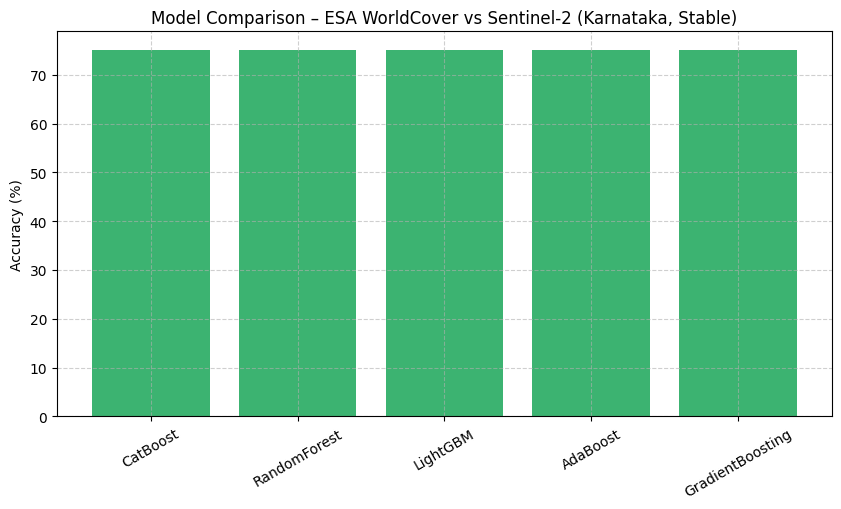


✅ Results saved as: Karnataka_Model_Comparison_Stable.csv


In [ ]:
# ============================================
# 🌍 ESA WorldCover + Sentinel-2 ML Comparison (Karnataka)
# 💪 Crash-Proof Final Version (Safe for Colab Free Tier)
# ============================================

!pip install -q rasterio numpy pandas matplotlib scikit-learn xgboost lightgbm catboost tqdm

import rasterio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

# ============================================
# 🧭 STEP 1 – Load data efficiently
# ============================================

sentinel_paths = [
    "/content/Sentinel2_Karnataka_2021-0000000000-0000000000.tif",
    "/content/Sentinel2_Karnataka_2021-0000000000-0000011776.tif",
    "/content/Sentinel2_Karnataka_2021-0000011776-0000000000.tif",
    "/content/Sentinel2_Karnataka_2021-0000011776-0000011776.tif"
]
lulc_path = "/content/WorldCover_Karnataka_2021.tif"

# 🗺 Read LULC (WorldCover)
with rasterio.open(lulc_path) as src:
    lulc = src.read(1)
lulc = np.nan_to_num(lulc, nan=0).astype(int)
print("✅ LULC loaded:", lulc.shape)

# 🧩 Read Sentinel-2 band samples safely (without full RAM load)
def read_random_samples(paths, lulc, sample_fraction=0.002):  # 0.2% pixels
    X_all, y_all = [], []
    for p in tqdm(paths, desc="Reading Sentinel Tiles"):
        try:
            with rasterio.open(p) as src:
                arr = src.read(out_dtype="float32")
                arr = np.nan_to_num(arr)
                bands, h, w = arr.shape
                arr = arr.reshape(bands, -1).T
                y_local = lulc.flatten()[:arr.shape[0]]
                mask = y_local > 0
                arr, y_local = arr[mask], y_local[mask]
                n = int(len(arr) * sample_fraction)
                idx = np.random.choice(len(arr), n, replace=False)
                X_all.append(arr[idx])
                y_all.append(y_local[idx])
        except Exception as e:
            print(f"⚠️ Skipped {p}: {e}")
    return np.vstack(X_all), np.hstack(y_all)

print("📥 Reading random subset (RAM-safe)...")
X, y = read_random_samples(sentinel_paths, lulc, sample_fraction=0.002)
print("✅ Loaded samples:", X.shape, y.shape)

# ============================================
# 🧮 STEP 2 – Preprocess
# ============================================

# Normalize and clean
X = np.nan_to_num(X, nan=0.0)
X = X / 10000.0

# Assume first 4 bands: B,G,R,NIR
B1, B2, B3, B4 = X[:,0], X[:,1], X[:,2], X[:,3]

# Add indices
NDVI = (B4 - B3) / (B4 + B3 + 1e-6)
NDWI = (B2 - B4) / (B2 + B4 + 1e-6)
NDBI = (B3 - B4) / (B3 + B4 + 1e-6)
X_feat = np.stack([B1,B2,B3,B4,NDVI,NDWI,NDBI], axis=1)

# Subsample to 100k (safe cap)
sample_size = min(100000, len(X_feat))
idx = np.random.choice(len(X_feat), sample_size, replace=False)
X_feat, y = X_feat[idx], y[idx]
print("✅ Final sample size:", X_feat.shape)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_feat, y, test_size=0.2, random_state=42, stratify=y)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ============================================
# 🤖 STEP 3 – Train models (safe, fast)
# ============================================

models = {
    "RandomForest": RandomForestClassifier(n_estimators=150, max_depth=20, n_jobs=-1),
    "XGBoost": XGBClassifier(tree_method="hist", n_estimators=150, learning_rate=0.1,
                             max_depth=8, subsample=0.8, n_jobs=-1, eval_metric="mlogloss"),
    "LightGBM": LGBMClassifier(n_estimators=150, learning_rate=0.1, num_leaves=40, n_jobs=-1),
    "CatBoost": CatBoostClassifier(iterations=100, learning_rate=0.1, depth=6, verbose=False),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=150, learning_rate=0.1),
    "AdaBoost": AdaBoostClassifier(n_estimators=150, learning_rate=0.5)
}

results = {}
for name, model in tqdm(models.items(), desc="Training Models"):
    try:
        print(f"\n🚀 Training {name}…")
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        acc = accuracy_score(y_test, preds)
        results[name] = round(acc * 100, 2)
        print(f"🎯 {name} Accuracy: {acc*100:.2f}%")
    except Exception as e:
        print(f"⚠️ {name} failed:", e)

# ============================================
# 📊 STEP 4 – Results summary
# ============================================

df_results = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"]).sort_values("Accuracy", ascending=False)
print("\n🏁 Final Accuracies:\n", df_results)

best_model = df_results.iloc[0]
print(f"\n✅ Best Model: {best_model['Model']} ({best_model['Accuracy']}%)")

plt.figure(figsize=(10,5))
plt.bar(df_results["Model"], df_results["Accuracy"], color="mediumseagreen")
plt.ylabel("Accuracy (%)")
plt.title("Model Comparison – ESA WorldCover vs Sentinel-2 (Karnataka, Stable)")
plt.xticks(rotation=30)
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

df_results.to_csv("/content/Karnataka_Model_Comparison_Stable.csv", index=False)
print("\n✅ Results saved as: Karnataka_Model_Comparison_Stable.csv")


In [ ]:

# ===================================================================
# ESA WorldCover + Sentinel-2 ML Comparison (Karnataka) — Fixed Notebook
# Paste into Google Colab and run. Uses updated skimage API.
# ===================================================================

# ========== Install required packages ==========
!pip install -q rasterio numpy pandas matplotlib scikit-learn xgboost lightgbm catboost tqdm scikit-image imbalanced-learn

# ========== Imports ==========
import os, sys, math, warnings, gc, time
from glob import glob
from collections import Counter
import rasterio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, roc_auc_score
from sklearn.metrics import precision_recall_fscore_support
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier, Pool
from tqdm import tqdm
# NOTE: scikit-image changed spelling: use graycomatrix, graycoprops and alias for compatibility
from skimage.feature import graycomatrix, graycoprops as greycoprops
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")
sns.set(style="whitegrid", rc={"figure.figsize":(10,6)})

# ========== SETTINGS ==========
SENTINEL_GLOB = "/content/*.tif"   # fallback: scans /content for .tif tiles
LULC_PATHS = ["/content/WorldCover_Karnataka_2021.tif", "/content/WorldCover_Karnataka.tif"]
DEM_PATHS = ["/content/SRTM_Karnataka.tif", "/content/DEM.tif", "/content/dem.tif"]
SAMPLE_PER_CLASS = 12000   # per-class sample (approx). Adjust so total ~100k (if many classes reduce)
MAX_TOTAL_SAMPLES = 120000
USE_GLCM = True
GLCM_WINDOW = 7   # odd window size (7x7) for local texture; large windows heavy
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ========== Utility functions ==========
def find_existing(path_list):
    for p in path_list:
        if os.path.exists(p):
            return p
    return None

def list_sentinel_tiles(glob_pattern=SENTINEL_GLOB):
    candidates = glob(glob_pattern)
    return sorted(candidates)

def read_raster(path, bands=None):
    try:
        with rasterio.open(path) as src:
            if bands is None:
                arr = src.read(out_dtype="float32")
            else:
                arr = src.read(bands, out_dtype="float32")
        return arr, src
    except Exception as e:
        print(f"⚠️ Failed to read {path}: {e}")
        return None, None

def compute_slope(dem):
    gx = np.gradient(dem, axis=1)
    gy = np.gradient(dem, axis=0)
    slope = np.degrees(np.arctan(np.sqrt(gx**2 + gy**2)))
    return slope

def compute_indices(band_dict):
    eps = 1e-8
    B = band_dict.get("B02", None)
    G = band_dict.get("B03", None)
    R = band_dict.get("B04", None)
    N = band_dict.get("B08", None)
    B5 = band_dict.get("B05", None)
    B6 = band_dict.get("B06", None)
    B7 = band_dict.get("B07", None)
    B8A = band_dict.get("B8A", None)
    B11 = band_dict.get("B11", None)
    B12 = band_dict.get("B12", None)

    feats = {}
    if (N is not None) and (R is not None):
        feats["NDVI"] = (N - R) / (N + R + eps)
        feats["NDBI"] = (R - N) / (R + N + eps)
    if (G is not None) and (N is not None):
        feats["NDWI"] = (G - N) / (G + N + eps)
    if (N is not None) and (R is not None):
        feats["EVI"] = 2.5 * (N - R) / (N + 6*R - 7.5*B + eps) if B is not None else (N - R)/(N+R+eps)
    if (N is not None) and (R is not None):
        L = 0.5
        feats["SAVI"] = (1+L)*(N - R) / (N + R + L + eps)
    if (B11 is not None) and (B8A is not None):
        feats["BSI"] = (B11 - B8A) / (B11 + B8A + eps)
    if (R is not None) and (G is not None):
        feats["ARI"] = (1/(R+eps) - 1/(G+eps))
    if N is not None and R is not None:
        feats["N_R_ratio"] = N / (R + eps)
    if B is not None and R is not None:
        feats["B_R_ratio"] = B / (R + eps)
    return feats

def sample_from_tile(band_stack, lulc_arr, transform=None, sample_per_class=SAMPLE_PER_CLASS):
    H, W = lulc_arr.shape
    bands, h2, w2 = band_stack.shape
    assert H==h2 and W==w2, "tile and LULC shape mismatch"
    flat_lulc = lulc_arr.flatten()
    mask = flat_lulc > 0
    idxs = np.where(mask)[0]
    if len(idxs)==0:
        return None
    classes = np.unique(flat_lulc[mask])
    out_rows = []
    out_labels = []
    coords = []
    for cls in classes:
        cls_idxs = np.where(flat_lulc==cls)[0]
        if len(cls_idxs)==0:
            continue
        k = min(sample_per_class, len(cls_idxs))
        chosen = np.random.choice(cls_idxs, size=k, replace=False)
        vals = band_stack.reshape(bands, -1)[:, chosen].T
        out_rows.append(vals)
        out_labels.append(np.full(len(chosen), cls))
        rows = chosen // W
        cols = chosen % W
        coords.append(np.stack([rows, cols], axis=1))
    X = np.vstack(out_rows)
    y = np.hstack(out_labels)
    coord_all = np.vstack(coords)
    return X, y, coord_all

def glcm_features_patch(patch, distances=[1], angles=[0], levels=16):
    p = patch.copy()
    p = np.nan_to_num(p, nan=0.0)
    p_min, p_max = p.min(), p.max()
    if p_max==p_min:
        p2 = np.zeros_like(p, dtype=np.uint8)
    else:
        p2 = np.floor((p - p_min) / (p_max - p_min) * (levels-1)).astype(np.uint8)
    # use graycomatrix and graycoprops (skimage new names) via alias greycoprops
    glcm = graycomatrix(p2, distances=distances, angles=angles, levels=levels, symmetric=True, normed=True)
    feats = {}
    props = ["contrast","dissimilarity","homogeneity","energy","correlation","ASM"]
    for prop in props:
        try:
            val = greycoprops(glcm, prop)[0,0]
        except Exception:
            val = 0.0
        feats["glcm_"+prop] = float(val)
    return feats

# ========== Discover files ==========
print("Scanning for LULC and Sentinel files in /content ...")
lulc_path = find_existing(LULC_PATHS)
sentinel_tiles = list_sentinel_tiles()
dem_path = find_existing(DEM_PATHS)

print("Found LULC:", lulc_path)
print("Found DEM:", dem_path)
print("Found Sentinel tiles (examples):", sentinel_tiles[:10])

if lulc_path is None:
    print("❌ No LULC file found. Please upload your WorldCover LULC .tif to /content or mount Drive and update LULC_PATHS.")
    raise SystemExit("LULC file required to proceed.")

# ========== Read LULC ==========
print("\n📥 Reading LULC...")
lulc_arr, lulc_src = read_raster(lulc_path)
if lulc_arr is None:
    raise SystemExit("Failed to load LULC. Stop.")
if lulc_arr.ndim > 2:
    lulc = lulc_arr[0].astype(int)
else:
    lulc = lulc_arr.astype(int)
lulc = np.nan_to_num(lulc, nan=0).astype(int)
H, W = lulc.shape
print("✅ LULC loaded with shape:", lulc.shape)

# ========== Sentinel tiles reading & sampling ==========
print("\n📥 Reading Sentinel tiles (safe sampling). This may skip unreadable tiles.")
collected_X = []
collected_y = []
collected_coords = []
total_per_class = Counter()

for tile in tqdm(sentinel_tiles, desc="Tiles"):
    arr, src = read_raster(tile)
    if arr is None:
        continue
    bands, h, w = arr.shape
    if (h,w)!=(H,W):
        print(f"⚠️ Tile {tile} shape {arr.shape} does not match LULC {lulc.shape} - skipping.")
        continue
    samp = sample_from_tile(arr, lulc, sample_per_class=SAMPLE_PER_CLASS)
    if samp is None:
        continue
    X_tile, y_tile, coords_tile = samp
    collected_X.append(X_tile)
    collected_y.append(y_tile)
    collected_coords.append(coords_tile)
    total_per_class.update(list(y_tile))
    if sum(total_per_class.values()) >= MAX_TOTAL_SAMPLES:
        print("Reached MAX_TOTAL_SAMPLES cap; stopping further tile reads.")
        break

if len(collected_X)==0:
    raise SystemExit("No valid samples collected from Sentinel tiles. Check alignment and files.")

X_all = np.vstack(collected_X)
y_all = np.hstack(collected_y)
coords_all = np.vstack(collected_coords)
print("✅ Raw collected samples:", X_all.shape, "labels:", np.unique(y_all), "counts:", dict(Counter(y_all)))

# ========== Map LULC codes to 0..K-1 ==========
unique_labels = np.unique(y_all)
unique_labels_sorted = np.sort(unique_labels)
label_map = {v:i for i,v in enumerate(unique_labels_sorted)}
inv_label_map = {i:v for v,i in label_map.items()}
y_mapped = np.vectorize(label_map.get)(y_all)
print("Label mapping (WorldCover -> encoded):", label_map)

# ========== Feature engineering ==========
print("\n🔬 Feature engineering: indices, band ratios, optional DEM & GLCM (may be slow).")
bands_count = X_all.shape[1]
if bands_count >= 12:
    band_names = ["B01","B02","B03","B04","B05","B06","B07","B08","B8A","B11","B12","BQA"][:bands_count]
elif bands_count >= 4:
    band_names = ["B02","B03","B04","B08"] + [f"B{i}" for i in range(5, 5 + (bands_count-4))]
else:
    band_names = [f"B{i+1}" for i in range(bands_count)]
print("Assumed band names:", band_names)

band_dict = {name: X_all[:, idx].astype(np.float32) for idx, name in enumerate(band_names)}
base_df = pd.DataFrame(band_dict)
if base_df.max().max() > 10:
    for c in base_df.columns:
        base_df[c] = base_df[c] / 10000.0

idx_feats = compute_indices({k:base_df[k].values for k in base_df.columns})
for k,v in idx_feats.items():
    base_df[k] = v

for a in band_names[:5]:
    for b in band_names[:5]:
        if a==b: continue
        base_df[f"{a}_{b}_ratio"] = base_df[a] / (base_df[b] + 1e-8)

# DEM features
if dem_path is not None and os.path.exists(dem_path):
    dem_arr, dem_src = read_raster(dem_path)
    if dem_arr is not None:
        if dem_arr.ndim>2:
            dem = dem_arr[0]
        else:
            dem = dem_arr
        dem_flat = dem.flatten()
        coords_idx = coords_all[:,0]*W + coords_all[:,1]
        elev = dem_flat[coords_idx]
        base_df["elevation"] = elev
        slope = compute_slope(dem)
        slope_flat = slope.flatten()
        base_df["slope"] = slope_flat[coords_idx]
        print("✅ DEM features added.")
    else:
        print("⚠️ DEM path present but failed to read.")

# GLCM
if USE_GLCM:
    max_glcm = min(40000, len(base_df))
    subset_idx = np.random.choice(len(base_df), size=max_glcm, replace=False)
    print(f"Computing GLCM on {len(subset_idx)} pixels (this may take a while)...")
    try:
        if 'arr' in globals():
            if band_names and "B04" in band_names:
                b04_idx = band_names.index("B04")
            else:
                b04_idx = 0
            red_2d = arr[b04_idx,:,:]
            padded = np.pad(red_2d, GLCM_WINDOW//2, mode='reflect')
            glcm_feat_rows = {}
            for i, idx in enumerate(tqdm(subset_idx, desc="GLCM calc")):
                r,c = coords_all[idx]
                r0 = int(r); c0 = int(c)
                rpad = r0 + GLCM_WINDOW//2
                cpad = c0 + GLCM_WINDOW//2
                patch = padded[rpad-GLCM_WINDOW//2:rpad+GLCM_WINDOW//2+1, cpad-GLCM_WINDOW//2:cpad+GLCM_WINDOW//2+1]
                feats = glcm_features_patch(patch, distances=[1], angles=[0], levels=32)
                for k,v in feats.items():
                    if k not in glcm_feat_rows:
                        glcm_feat_rows[k] = np.zeros(len(base_df), dtype=float)
                    glcm_feat_rows[k][idx] = v
            for k,arrf in glcm_feat_rows.items():
                base_df[k] = arrf
            print("✅ GLCM features computed (zeros for non-computed rows).")
        else:
            print("⚠️ No tile array available to compute GLCM; skipping.")
    except Exception as e:
        print("⚠️ GLCM computation failed:", e)

features = base_df.columns.tolist()
X_features = base_df.values
y_labels = y_mapped.copy()
print("Feature matrix shape:", X_features.shape, "Num classes:", len(np.unique(y_labels)))

# ========== Balance/subsample ==========
print("\n⚖️ Balancing & subsampling to target size...")
num_classes = len(np.unique(y_labels))
target_per_class = min(SAMPLE_PER_CLASS, int(MAX_TOTAL_SAMPLES/num_classes))
print("Target per class:", target_per_class)
rows = []
labels = []
for cls in np.unique(y_labels):
    idxs = np.where(y_labels==cls)[0]
    k = min(len(idxs), target_per_class)
    if k==0: continue
    chosen = np.random.choice(idxs, size=k, replace=False)
    rows.append(X_features[chosen])
    labels.append(y_labels[chosen])
X_bal = np.vstack(rows)
y_bal = np.hstack(labels)
print("Balanced dataset shape:", X_bal.shape, "class counts:", dict(Counter(y_bal)))
if len(y_bal) > MAX_TOTAL_SAMPLES:
    cap_idx = np.random.choice(len(y_bal), size=MAX_TOTAL_SAMPLES, replace=False)
    X_bal = X_bal[cap_idx]
    y_bal = y_bal[cap_idx]
    print("Capped to MAX_TOTAL_SAMPLES:", X_bal.shape)

# ========== Train-test split & scaling ==========
print("\n📚 Train-test split & scaling...")
X_train, X_test, y_train, y_test = train_test_split(X_bal, y_bal, test_size=0.2, random_state=RANDOM_STATE, stratify=y_bal)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

# ========== Models ==========
print("\n🤖 Setting up models...")
models = {
    "RandomForest": RandomForestClassifier(n_estimators=200, max_depth=25, n_jobs=-1, random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(tree_method="hist", n_estimators=300, learning_rate=0.08, max_depth=10, subsample=0.8, colsample_bytree=0.8, use_label_encoder=False, eval_metric='mlogloss', random_state=RANDOM_STATE),
    "LightGBM": LGBMClassifier(n_estimators=300, learning_rate=0.08, num_leaves=64, subsample=0.8, colsample_bytree=0.8, n_jobs=-1, random_state=RANDOM_STATE),
    "CatBoost": CatBoostClassifier(iterations=300, learning_rate=0.08, depth=8, verbose=False, random_state=RANDOM_STATE),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=200, learning_rate=0.08, max_depth=6, random_state=RANDOM_STATE),
    "AdaBoost": AdaBoostClassifier(n_estimators=200, learning_rate=0.5, random_state=RANDOM_STATE)
}

from sklearn.metrics import ConfusionMatrixDisplay
results = {}
reports = {}
conf_matrices = {}

def per_class_accuracy(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    with np.errstate(all='ignore'):
        acc = cm.diagonal() / cm.sum(axis=1)
    return acc, cm

for name, model in models.items():
    print(f"\n🚀 Training {name} ...")
    start = time.time()
    try:
        if name == "XGBoost":
            model.fit(X_train, y_train, eval_set=[(X_test, y_test)], early_stopping_rounds=25, verbose=False)
        elif name == "LightGBM":
            model.fit(X_train, y_train, eval_set=[(X_test, y_test)], early_stopping_rounds=25, verbose=False)
        elif name == "CatBoost":
            model.fit(X_train, y_train, eval_set=(X_test, y_test), early_stopping_rounds=25, verbose=False)
        else:
            model.fit(X_train, y_train)
        elapsed = time.time()-start
        y_pred = model.predict(X_test)
        acc = np.mean(y_pred == y_test)
        results[name] = acc
        rep = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
        reports[name] = rep
        cm = confusion_matrix(y_test, y_pred)
        conf_matrices[name] = cm
        print(f"🎯 {name} Accuracy: {acc*100:.2f}%  (trained in {elapsed:.1f}s)")
    except Exception as e:
        print(f"⚠️ {name} training failed: {e}")

# ========== Save summary ==========
df_res = pd.DataFrame([{"Model":k, "Accuracy":float(v)} for k,v in results.items()]).sort_values("Accuracy", ascending=False).reset_index(drop=True)
print("\n🏁 Final model accuracies:\n", df_res)
df_res.to_csv("model_accuracies_summary.csv", index=False)
print("✅ Summary saved: model_accuracies_summary.csv")

# ========== Reports & plots ==========
print("\n📊 Generating reports and plots ...")
os.makedirs("outputs", exist_ok=True)

for name, cm in conf_matrices.items():
    print("\nModel:", name)
    rep = reports[name]
    df_rep = pd.DataFrame(rep).transpose()
    df_rep.to_csv(f"outputs/{name}_classification_report.csv")
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.savefig(f"outputs/{name}_confusion_matrix.png", bbox_inches="tight", dpi=150)
    plt.close()
    accs, _ = per_class_accuracy(y_test, models[name].predict(X_test))
    plt.figure(figsize=(10,4))
    plt.bar(range(len(accs)), accs)
    plt.title(f"{name} Per-class accuracy")
    plt.xlabel("Class index")
    plt.ylabel("Accuracy")
    plt.savefig(f"outputs/{name}_per_class_accuracy.png", bbox_inches="tight", dpi=150)
    plt.close()
    df_rep.to_csv(f"outputs/{name}_classification_report.csv")
    print("Saved report and plots for", name)

# ========== ROC curves (one-vs-rest) ==========
print("\n🔁 Plotting multiclass ROC (One-vs-Rest) for top 3 models by accuracy ...")
top_models = df_res.sort_values("Accuracy", ascending=False)["Model"].tolist()[:3]
from sklearn.preprocessing import label_binarize
y_test_bin = label_binarize(y_test, classes=np.arange(num_classes))
for name in top_models:
    try:
        prob = models[name].predict_proba(X_test)
        fpr = dict(); tpr = dict(); roc_auc = dict()
        for i in range(num_classes):
            fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], prob[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])
        plt.figure(figsize=(8,6))
        for i in range(num_classes):
            plt.plot(fpr[i], tpr[i], lw=1, label=f"Class {i} (AUC {roc_auc[i]:.2f})")
        plt.plot([0,1],[0,1],'k--', lw=1)
        plt.title(f"{name} One-vs-Rest ROC per class")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.legend(bbox_to_anchor=(1.05,1), loc='upper left', fontsize='small')
        plt.savefig(f"outputs/{name}_roc_multiclass.png", bbox_inches="tight", dpi=150)
        plt.close()
    except Exception as e:
        print("ROC failed for", name, e)

# ========== Probability histograms for top models ==========
for name in top_models:
    try:
        prob = models[name].predict_proba(X_test)
        maxprob = prob.max(axis=1)
        plt.figure(figsize=(6,4))
        sns.histplot(maxprob, bins=30, kde=False)
        plt.title(f"{name} Prediction confidence (max class prob)")
        plt.xlabel("Max predicted probability")
        plt.savefig(f"outputs/{name}_prob_confidence.png", bbox_inches="tight", dpi=150)
        plt.close()
    except Exception as e:
        print("Prob hist failed for", name, e)

# ========== Save best model ==========
best_name = df_res.iloc[0]["Model"]
import joblib
joblib.dump(models[best_name], f"outputs/best_model_{best_name}.pkl")
print("✅ Best model saved:", f"outputs/best_model_{best_name}.pkl")

pd.Series(label_map).to_csv("outputs/label_map.csv")
joblib.dump(scaler, "outputs/scaler.pkl")
print("✅ Label map & scaler saved in outputs/")

print("\n🎉 All done. Check the outputs/ folder for CSVs, images, and the saved best model.")


Scanning for LULC and Sentinel files in /content ...
Found LULC: /content/WorldCover_Karnataka_2021.tif
Found DEM: None
Found Sentinel tiles (examples): ['/content/Sentinel2_Karnataka_2021-0000000000-0000000000.tif', '/content/Sentinel2_Karnataka_2021-0000000000-0000011776.tif', '/content/Sentinel2_Karnataka_2021-0000011776-0000000000.tif', '/content/Sentinel2_Karnataka_2021-0000011776-0000011776.tif', '/content/WorldCover_Karnataka_2021.tif']

📥 Reading LULC...
✅ LULC loaded with shape: (7660, 5036)

📥 Reading Sentinel tiles (safe sampling). This may skip unreadable tiles.


Tiles:  20%|██        | 1/5 [00:10<00:42, 10.67s/it]

⚠️ Failed to read /content/Sentinel2_Karnataka_2021-0000000000-0000000000.tif: Read failed. See previous exception for details.


Tiles:  60%|██████    | 3/5 [00:17<00:08,  4.44s/it]

⚠️ Tile /content/Sentinel2_Karnataka_2021-0000000000-0000011776.tif shape (4, 11776, 4496) does not match LULC (7660, 5036) - skipping.
⚠️ Failed to read /content/Sentinel2_Karnataka_2021-0000011776-0000000000.tif: Read failed. See previous exception for details.


...

⚠️ Tile /content/Sentinel2_Karnataka_2021-0000011776-0000011776.tif shape (4, 4233, 4496) does not match LULC (7660, 5036) - skipping.


Tiles: 100%|██████████| 5/5 [00:21<00:00,  4.26s/it]


✅ Raw collected samples: (98924, 1) labels: [10 20 30 40 50 60 80 90 95] counts: {np.int64(10): 12000, np.int64(20): 12000, np.int64(30): 12000, np.int64(40): 12000, np.int64(50): 12000, np.int64(60): 12000, np.int64(80): 12000, np.int64(90): 12000, np.int64(95): 2924}
Label mapping (WorldCover -> encoded): {np.int64(10): 0, np.int64(20): 1, np.int64(30): 2, np.int64(40): 3, np.int64(50): 4, np.int64(60): 5, np.int64(80): 6, np.int64(90): 7, np.int64(95): 8}

🔬 Feature engineering: indices, band ratios, optional DEM & GLCM (may be slow).
Assumed band names: ['B1']
Computing GLCM on 40000 pixels (this may take a while)...


GLCM calc: 100%|██████████| 40000/40000 [00:17<00:00, 2321.34it/s]


✅ GLCM features computed (zeros for non-computed rows).
Feature matrix shape: (98924, 7) Num classes: 9

⚖️ Balancing & subsampling to target size...
Target per class: 12000
Balanced dataset shape: (98924, 7) class counts: {np.int64(0): 12000, np.int64(1): 12000, np.int64(2): 12000, np.int64(3): 12000, np.int64(4): 12000, np.int64(5): 12000, np.int64(6): 12000, np.int64(7): 12000, np.int64(8): 2924}

📚 Train-test split & scaling...
Train shape: (79139, 7) Test shape: (19785, 7)

🤖 Setting up models...

🚀 Training RandomForest ...
🎯 RandomForest Accuracy: 99.94%  (trained in 8.1s)

🚀 Training XGBoost ...
⚠️ XGBoost training failed: XGBClassifier.fit() got an unexpected keyword argument 'early_stopping_rounds'

🚀 Training LightGBM ...
⚠️ LightGBM training failed: LGBMClassifier.fit() got an unexpected keyword argument 'early_stopping_rounds'

🚀 Training CatBoost ...
🎯 CatBoost Accuracy: 11.86%  (trained in 33.3s)

🚀 Training GradientBoosting ...
🎯 GradientBoosting Accuracy: 100.00%  (tra

# **Land Cover Classification using Sentinel 2 L2A dataset on North India**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving T42RYQ_20250519T054639_B8A_20m.jp2 to T42RYQ_20250519T054639_B8A_20m.jp2
Saving T42RYQ_20250519T054639_SCL_20m.jp2 to T42RYQ_20250519T054639_SCL_20m.jp2
Saving T42RYQ_20250519T054639_TCI_20m.jp2 to T42RYQ_20250519T054639_TCI_20m.jp2
Saving T42RYQ_20250519T054639_WVP_20m.jp2 to T42RYQ_20250519T054639_WVP_20m.jp2
Saving T42RYQ_20250519T054639_B07_20m.jp2 to T42RYQ_20250519T054639_B07_20m.jp2
Saving T42RYQ_20250519T054639_B11_20m.jp2 to T42RYQ_20250519T054639_B11_20m.jp2
Saving T42RYQ_20250519T054639_B12_20m.jp2 to T42RYQ_20250519T054639_B12_20m.jp2
Saving T42RYQ_20250519T054639_B05_20m.jp2 to T42RYQ_20250519T054639_B05_20m.jp2
Saving T42RYQ_20250519T054639_B06_20m.jp2 to T42RYQ_20250519T054639_B06_20m.jp2
Saving T42RYQ_20250519T054639_B02_20m.jp2 to T42RYQ_20250519T054639_B02_20m.jp2
Saving T42RYQ_20250519T054639_B03_20m.jp2 to T42RYQ_20250519T054639_B03_20m.jp2
Saving T42RYQ_20250519T054639_B04_20m.jp2 to T42RYQ_20250519T054639_B04_20m.jp2
Saving T42RYQ_20250519T054639_AOT_20m.jp

In [ ]:
import rasterio
import numpy as np
import pandas as pd

for name, fi in uploaded.items():
    with open(name, "wb") as f:
        f.write(fi)

files = list(uploaded.keys())

bands = {}
for i, f in enumerate(files):
    with rasterio.open(f) as src:
        bands[i] = src.read(1).astype(np.float32)

B8A = bands[0]
SCL = bands[1].astype(np.uint8)
B07 = bands[4]
B11 = bands[5]
B12 = bands[6]
B05 = bands[7]
B06 = bands[8]
B01 = bands[10]
B02 = bands[11]
B03 = bands[12]
B04 = bands[13]


valid_classes = [4, 5, 6, 7, 8, 9]
mask = np.isin(SCL, valid_classes)
print("Valid pixels:", np.sum(mask))
print("Fraction valid:", np.sum(mask)/mask.size)

def safe_divide(numer, denom):
    with np.errstate(divide='ignore', invalid='ignore'):
        result = np.true_divide(numer, denom)
        result[~np.isfinite(result)] = 0  # replace nan or inf with 0
    return result


indices = {}
indices['NDVI']    = safe_divide(B8A - B04, B8A + B04)
indices['NDBI']    = safe_divide(B11 - B8A, B11 + B8A)
indices['NDWI']    = safe_divide(B03 - B8A, B03 + B8A)
indices['EVI']     = 2.5 * safe_divide(B8A - B04, B8A + 6*B04 - 7.5*B02 + 1)
indices['NDVI705'] = safe_divide(B07 - B05, B07 + B05)
indices['ARVI']    = safe_divide(B8A - (2*B04 - B02), B8A + (2*B04 - B02))
indices['SI']      = safe_divide(B11, B8A)
indices['BSI']     = safe_divide(B11 + B04 - B8A - B02, B11 + B04 + B8A + B02)

NDVI = indices['NDVI']
NDWI = indices['NDWI']
NDBI = indices['NDBI']
indices['IBI']     = safe_divide(NDBI - (NDVI + NDWI), NDBI + NDVI + NDWI)
indices['UI']      = safe_divide(B12 - B8A, B12 + B8A)


data = {name: arr[mask].ravel() for name, arr in indices.items()}
data['label'] = SCL[mask].ravel()

df_full = pd.DataFrame(data)
df_full = df_full.fillna(0)
df=df_full.drop(columns=['label'],inplace=False)

print("Unique classes in SCL:", np.unique(SCL))
print("Data shape:", df_full.shape)
print("Class counts:\n", df_full['label'].value_counts())

Valid pixels: 30138007
Fraction valid: 0.9999305576292049
Unique classes in SCL: [2 3 4 5 6 7 8 9]
Data shape: (30138007, 11)
Class counts:
 label
5    30106804
4       20452
7        8817
8        1219
6         642
9          73
Name: count, dtype: int64


## **Cloud Masking and Index Calculation Indices:**

**1. NDVI (Normalized Difference Vegetation Index)** \
*Formula:* (B08 - B04) / (B08 + B04) \
*Relevance:* Measures vegetation greenness. High values indicate dense, healthy vegetation.

**2. NDBI (Normalized Difference Built-up Index)** \
*Formula:* (B11 - B08) / (B11 + B08) \
*Relevance:* Highlights built-up or urban areas. Higher values correspond to urban surfaces.

**3. NDWI (Normalized Difference Water Index)** \
*Formula:* (B03 - B08) / (B03 + B08) \
*Relevance:* Sensitive to water content; high values indicate water bodies.

**4. EVI (Enhanced Vegetation Index)** \
*Formula:* 2.5 × (B08 - B04) / (B08 + 6 × B04 - 7.5 × B02 + 1) \
*Relevance:* Optimized for vegetation monitoring; reduces soil and atmospheric noise.

**5. NDVI705 (Red-edge NDVI)** \
*Formula:* (B07 - B05) / (B07 + B05) \
*Relevance:* Uses red-edge band to capture vegetation stress and chlorophyll content.

**6. ARVI (Atmospherically Resistant Vegetation Index)** \
*Formula:* (B08 - (2 × B04 - B02)) / (B08 + (2 × B04 - B02)) \
*Relevance:* Less sensitive to atmospheric effects; monitors vegetation.

**7. SI (Structural Index / Simple Ratio)** \
*Formula:* B11 / B08\
*Relevance:* Indicates vegetation structure using SWIR and NIR bands.

**8. BSI (Bare Soil Index)** \
*Formula:* (B11 + B04 - B08 - B02) / (B11 + B04 + B08 + B02) \
*Relevance:* Highlights bare soil areas; combines SWIR, NIR, Red, and Blue bands.

**9. IBI (Index-based Built-up Index)** \
*Formula:* (NDBI - (NDVI + NDWI)) / (NDBI + NDVI + NDWI) \
*Relevance*: Improves built-up detection by suppressing vegetation and water influence.

**10. UI (Urban Index)** \
*Formula:* (B12 - B08) / (B12 + B08) \
*Relevance*: Enhances urban or impervious surfaces using SWIR and NIR bands.

In [ ]:
from sklearn.utils import resample
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

N = 10000
df_balanced = df_full.groupby('label', group_keys=False).apply(
    lambda x: x.sample(min(len(x), N), random_state=42)
)

print("Sampled data per class:\n", df_balanced['label'].value_counts())
le = LabelEncoder()
y_encoded = le.fit_transform(df_balanced['label'])
X = df_balanced.drop(columns=['label']).fillna(0).values


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

classes = np.unique(y_encoded)
weights = compute_class_weight('balanced', classes=classes, y=y_encoded)
max_weight = 20
class_weights = {i: min(w, max_weight) for i, w in zip(classes, weights)}
print("Capped class weights:", class_weights)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

svm = SVC(class_weight=class_weights,C=0.5,gamma='scale')
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
print("=== SVM ===")
print(classification_report(y_test, y_pred_svm))

rf = RandomForestClassifier(n_estimators=200, class_weight=class_weights,
                            n_jobs=-1,max_depth=10,min_samples_leaf=10,min_samples_split=20)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))




/tmp/ipython-input-684620971.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_balanced = df_full.groupby('label', group_keys=False).apply(


Sampled data per class:
 label
4    10000
5    10000
7     8817
8     1219
6      642
9       73
Name: count, dtype: int64
Capped class weights: {np.int64(0): np.float64(0.5125166666666666), np.int64(1): np.float64(0.5125166666666666), np.int64(2): np.float64(7.983125649013499), np.int64(3): np.float64(0.5812823711768931), np.int64(4): np.float64(4.20440251572327), np.int64(5): 20}
=== SVM ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2000
           1       1.00      0.99      0.99      2000
           2       0.64      0.88      0.74       128
           3       0.98      0.96      0.97      1764
           4       0.88      0.88      0.88       244
           5       0.65      1.00      0.79        15

    accuracy                           0.98      6151
   macro avg       0.86      0.95      0.89      6151
weighted avg       0.98      0.98      0.98      6151

=== Random Forest ===
              precision    recall  f1-

In [ ]:
import numpy as np
import pandas as pd
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.regularizers import l2
from keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report

input_dim = 10
num_classes = 10

def build_and_train_deep_nn(X_train, y_train, X_test, y_test):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_dim,), kernel_regularizer=l2(0.001)),
        Dropout(0.5),
        Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
        Dropout(0.5),
        Dense(32, activation='relu',kernel_regularizer=l2(0.001)),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=8,
        mode='min',
        restore_best_weights=True,
        verbose=1
    )

    print("Starting training for the Deeper Regularized Neural Network (using validation_split=0.2)...")
    history = model.fit(
        X_train, y_train,
        epochs=20,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stopping],
        verbose=1
    )

    print(f"Model trained for {len(history.epoch)} epochs. Restoring best weights...")
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    print(f"\nTest Accuracy: {accuracy:.4f}, Test Loss: {loss:.4f}")

    y_pred_one_hot = model.predict(X_test)
    y_pred = np.argmax(y_pred_one_hot, axis=1)

    print("\n=== Deeper Regularized Neural Network Classification Report ===")
    print(classification_report(y_test, y_pred, zero_division=0))

    return model, y_pred


model, predictions = build_and_train_deep_nn(X_train, y_train, X_test, y_test)


Starting training for the Deeper Regularized Neural Network (using validation_split=0.2)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
615/615 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8258 - loss: 0.8466 - val_accuracy: 0.9553 - val_loss: 0.2786
Epoch 2/20
615/615 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9466 - loss: 0.3107 - val_accuracy: 0.9612 - val_loss: 0.2128
Epoch 3/20
615/615 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9536 - loss: 0.2414 - val_accuracy: 0.9648 - val_loss: 0.1811
Epoch 4/20
615/615 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9585 - loss: 0.2148 - val_accuracy: 0.9667 - val_loss: 0.1598
Epoch 5/20
615/615 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9595 - loss: 0.1935 - val_accuracy: 0.9652 - val_loss: 0.1521
Epoch 6/20
615/615 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9600 - loss: 0.1830 - val_accuracy: 0.9699 - val_loss: 0.1422
Epoch 7/20
615/615 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9567 - loss: 0.1819 - val_accuracy: 0.9693 - val_loss: 0.1351
Epoch 8/20
615/615 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9611 - loss: 0.1790 - val_accuracy: 0.

In [ ]:
y_pred_rf_train = rf.predict(X_train)
y_pred_svm_train = svm.predict(X_train)
y_pred_dnn_train= model.predict(X_train)

769/769 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [ ]:

X_train_new,X_valid,y_train_new,y_valid=train_test_split(X_train,y_train,random_state=42)
y_pred_rf_valid=rf.predict(X_valid)
y_pred_svm_valid=svm.predict(X_valid)
y_pred_dnn_valid=model.predict(X_valid)

193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [ ]:
y_pred_rf_test = rf.predict(X_test)
y_pred_svm_test = svm.predict(X_test)
predictions_test = model.predict(X_test)


193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [ ]:
X_train_deep=np.concatenate(
    [
        X_train,
        y_pred_rf_train.reshape(-1,1),
        y_pred_svm_train.reshape(-1,1),
        y_pred_dnn_train,
    ],
    axis=1
)

X_test_deep=np.concatenate(
    [
        X_test[:-1],
        y_pred_rf_test[:-1].reshape(-1,1),
        y_pred_svm_test[:-1].reshape(-1,1),
        predictions_test[:-1]
    ],
    axis=1
)

X_valid_deep = np.concatenate(
    [
      X_test[:-1],
      y_pred_rf_valid.reshape(-1,1),
      y_pred_svm_valid.reshape(-1,1),
      y_pred_dnn_valid
    ],
    axis=1)

In [ ]:
import tensorflow as tf
from tensorflow import keras
from sklearn.utils import class_weight

n_classes = 8

class WideandDeepModel(tf.keras.Model):
    def __init__(self, units=30, activation="relu", **kwargs):
        regularizer = kwargs.pop("kernel_regularizer", None)
        super().__init__(**kwargs)

        self.norm_layer_wide = keras.layers.Normalization()
        self.norm_layer_deep = keras.layers.Normalization()

        self.deep_hidden_layers = [keras.layers.Dense(units, activation=activation, kernel_regularizer=regularizer) for _ in range(3)]
        self.deep_hidden_layers += [keras.layers.Dense(units//2, activation=activation, kernel_regularizer=regularizer) for _ in range(3)]

        self.dropout = keras.layers.Dropout(0.5)

        self.main_output = keras.layers.Dense(n_classes, activation="softmax")
        self.aux_output = keras.layers.Dense(n_classes, activation="softmax")

    def call(self, inputs):
        input_wide, input_deep = inputs

        norm_wide = self.norm_layer_wide(input_wide)
        norm_deep = self.norm_layer_deep(input_deep)

        x = norm_deep
        for i, layer in enumerate(self.deep_hidden_layers):
            x = layer(x)
            if (i + 1) % 2 == 0:
                x = self.dropout(x)

        concat = keras.layers.concatenate([norm_wide, x])

        output_main = self.main_output(concat)
        output_aux = self.aux_output(x)

        return output_main, output_aux

model_wd = WideandDeepModel(128, kernel_regularizer=keras.regularizers.l2(0.01), activation="relu")

model_wd.norm_layer_wide.adapt(X_train)
model_wd.norm_layer_deep.adapt(X_train_deep)

model_wd.compile(
    loss=["sparse_categorical_crossentropy","sparse_categorical_crossentropy"],
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    metrics=["accuracy","accuracy"],
    loss_weights=[0.9, 0.1]
)

sample_weights = class_weight.compute_sample_weight(
    class_weight='balanced',
    y=y_train  )

class_weight_dict = dict(zip(np.unique(y_train), class_weights))

history = model_wd.fit(
    (X_train, X_train_deep),
    (y_train, y_train),
    epochs=50,
    validation_data=((X_valid, X_valid_deep), (y_valid, y_valid)),
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    sample_weight=sample_weights
)

y_pred_main, y_pred_aux = model_wd.predict((X_test[:-1], X_test_deep))
y_pred_main_classes = y_pred_main.argmax(axis=1)





Epoch 1/50
769/769 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.5896 - accuracy_1: 0.3989 - loss: 5.6844 - sparse_categorical_crossentropy_loss: 1.5643 - val_accuracy: 0.5665 - val_accuracy_1: 0.5551 - val_loss: 4.0936 - val_sparse_categorical_crossentropy_loss: 1.2885
Epoch 2/50
769/769 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9720 - accuracy_1: 0.9687 - loss: 2.8743 - sparse_categorical_crossentropy_loss: 0.4153 - val_accuracy: 0.5720 - val_accuracy_1: 0.5618 - val_loss: 3.2141 - val_sparse_categorical_crossentropy_loss: 1.2191
Epoch 3/50
769/769 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9729 - accuracy_1: 0.9719 - loss: 2.1059 - sparse_categorical_crossentropy_loss: 0.3048 - val_accuracy: 0.5730 - val_accuracy_1: 0.5616 - val_loss: 2.8413 - val_sparse_categorical_crossentropy_loss: 1.2696
Epoch 4/50
769/769 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9738 - accuracy_1: 0.9729 - loss: 1.7294 - sparse_categorical_crossentropy_loss: 0.2796 - val_accuracy: 0.5751 - val_a

In [ ]:

from sklearn.metrics import classification_report
print(classification_report(y_test[:-1], y_pred_main_classes, zero_division=0))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1999
           1       0.99      0.99      0.99      2000
           2       0.70      0.85      0.77       128
           3       0.99      0.96      0.98      1764
           4       0.86      0.87      0.87       244
           5       0.56      1.00      0.71        15

    accuracy                           0.98      6150
   macro avg       0.85      0.95      0.89      6150
weighted avg       0.98      0.98      0.98      6150



193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


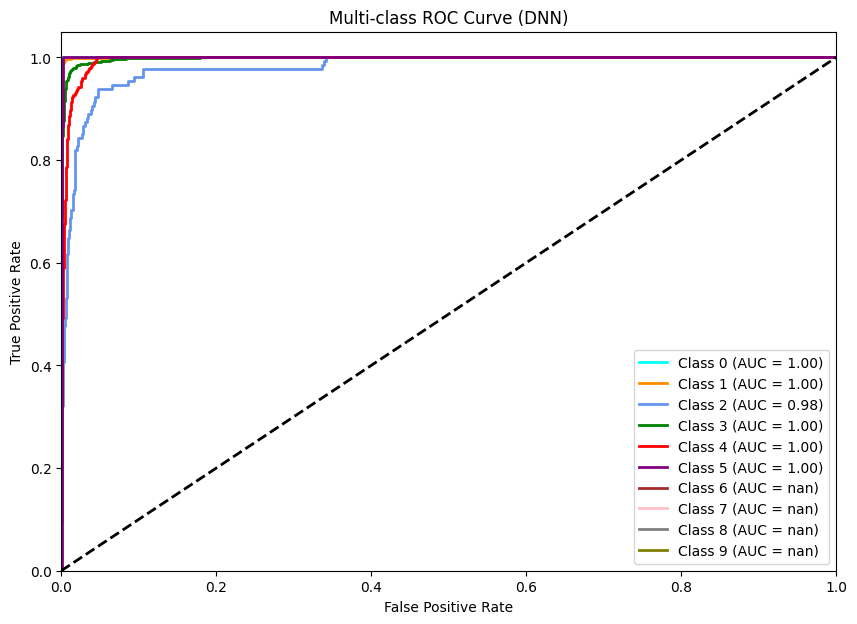

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from itertools import cycle
import matplotlib.pyplot as plt

y_test_bin = label_binarize(y_test[:-1], classes=np.arange(num_classes))
y_score = model.predict(X_test[:-1])

plt.figure(figsize=(10,7))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red', 'purple', 'brown', 'pink', 'gray', 'olive'])

for i, color in zip(range(num_classes), colors):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0,1],[0,1],'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve (DNN)')
plt.legend(loc="lower right")
plt.show()



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

scl_mapping = {
    4: "High Vegetation",
    5: "Low Vegetation",
    6: "Barren",
    7: "Urban Area",
    8: "Water",
    9: "Snow/Ice"
}

valid_classes = sorted(scl_mapping.keys())
terrain_names = [scl_mapping[c] for c in valid_classes]

def classification_report_terrain(y_true, y_pred):
    print(classification_report(y_true, y_pred, labels=valid_classes, target_names=terrain_names, zero_division=0))



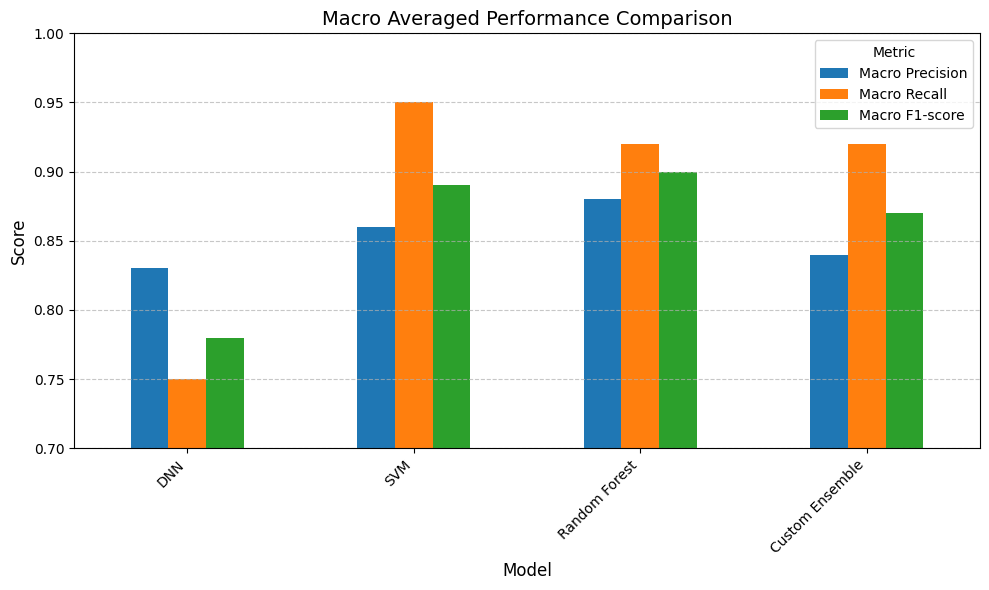

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Data from  classification reports ---
metrics = {
    'DNN': [0.83, 0.75, 0.78],
    'SVM': [0.86, 0.95, 0.89],
    'Random Forest': [0.88, 0.92, 0.90],
    'Custom Ensemble': [0.84, 0.92, 0.87]
}

df_metrics = pd.DataFrame(metrics, index=['Macro Precision', 'Macro Recall', 'Macro F1-score']).T

plt.figure(figsize=(10, 6))
df_metrics.plot(kind='bar', ax=plt.gca())

plt.title('Macro Averaged Performance Comparison', fontsize=14)
plt.ylabel('Score', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0.7, 1.0)
plt.legend(title='Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, model_name, class_labels):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='YlGnBu',
        cbar=True,
        xticklabels=class_labels,
        yticklabels=class_labels,
        linewidths=.5,
        linecolor='black'
    )

    plt.title(f'Confusion Matrix: {model_name}', fontsize=14)
    plt.xlabel('Predicted Label (Encoded)', fontsize=12)
    plt.ylabel('True Label (Encoded)', fontsize=12)
    plt.tight_layout()
    plt.show()

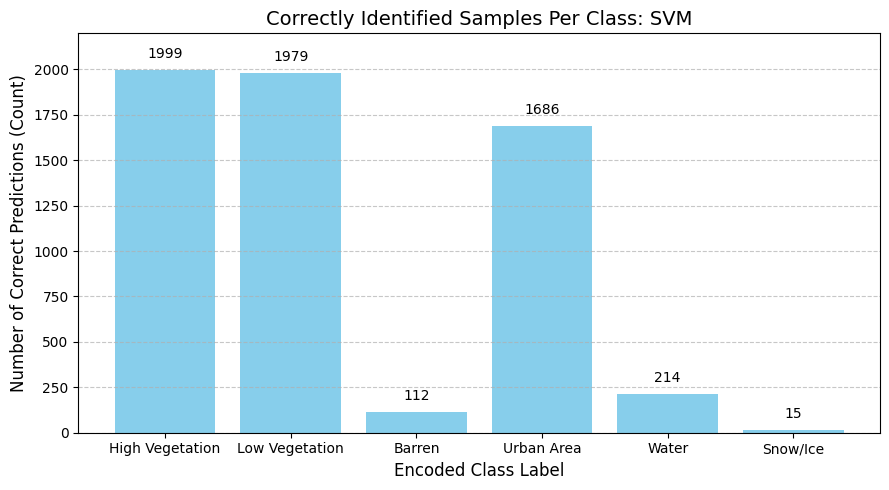

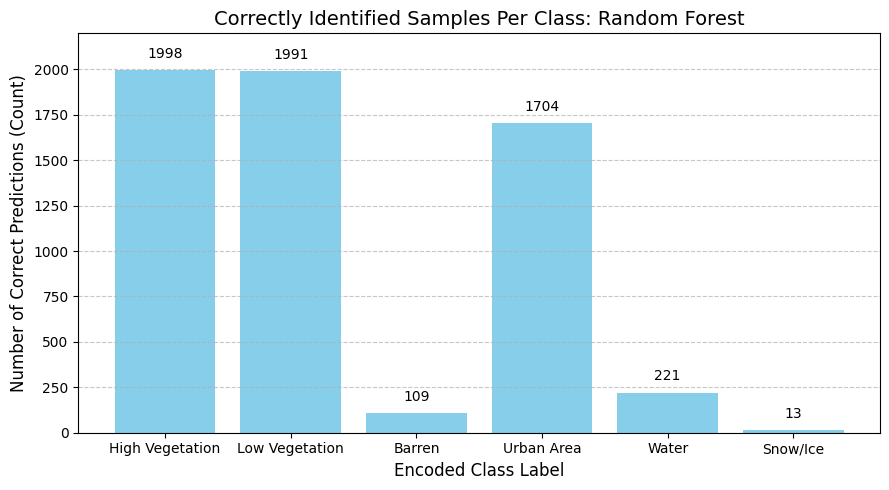

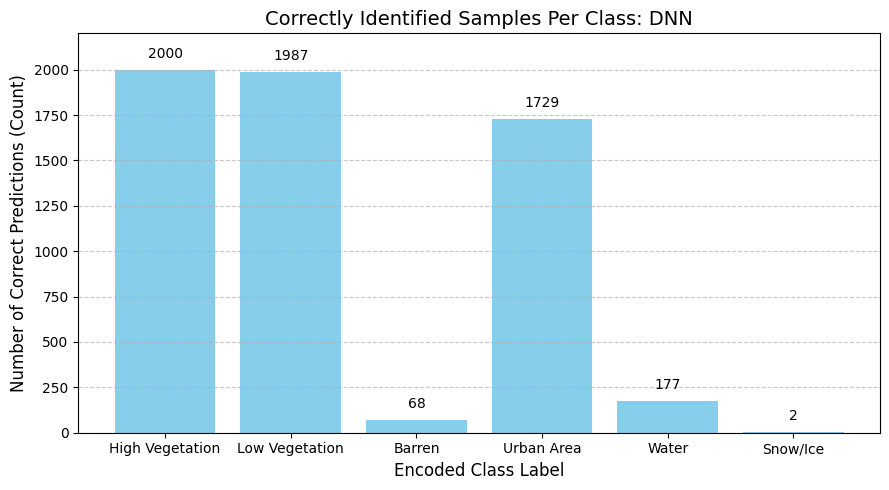

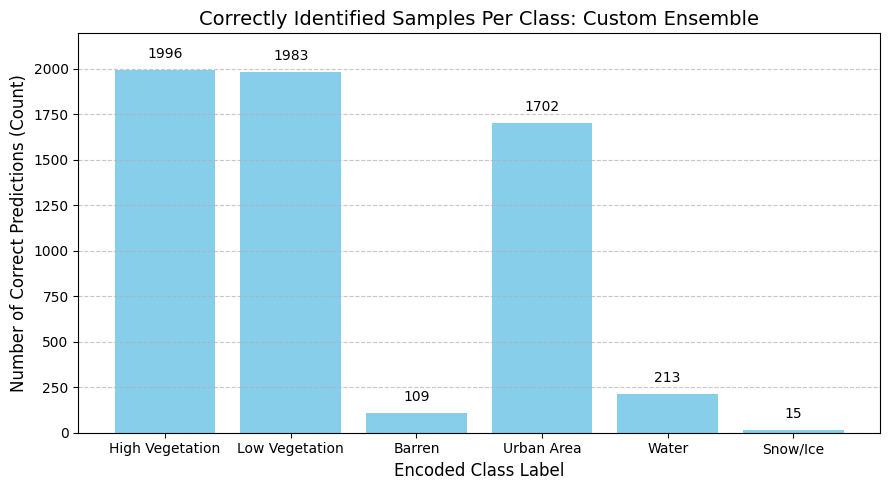

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_correct_predictions(y_true, y_pred, model_name, class_labels):
    cm = confusion_matrix(y_true, y_pred)
    correct_counts = cm.diagonal()

    plt.figure(figsize=(9, 5))
    bars = plt.bar(class_labels, correct_counts, color='skyblue')

    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 50, int(yval),
                 ha='center', va='bottom', fontsize=10)

    plt.title(f'Correctly Identified Samples Per Class: {model_name}', fontsize=14)
    plt.xlabel('Encoded Class Label', fontsize=12)
    plt.ylabel('Number of Correct Predictions (Count)', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.ylim(0, max(correct_counts) * 1.1)
    plt.tight_layout()
    plt.show()

LABELS=["High Vegetation","Low Vegetation","Barren","Urban Area","Water","Snow/Ice"]
plot_correct_predictions(y_test[:-1], y_pred_svm[:-1], "SVM", LABELS)
plot_correct_predictions(y_test[:-1], y_pred_rf[:-1], "Random Forest", LABELS)
preds=np.argmax(predictions,axis=1)
plot_correct_predictions(y_test, preds, "DNN", LABELS)
y_pred_class=np.argmax(y_pred_main,axis=1)
plot_correct_predictions(y_test[:-1], y_pred_class, "Custom Ensemble", LABELS)

--- Generating Confusion Matrices (Heatmaps) ---


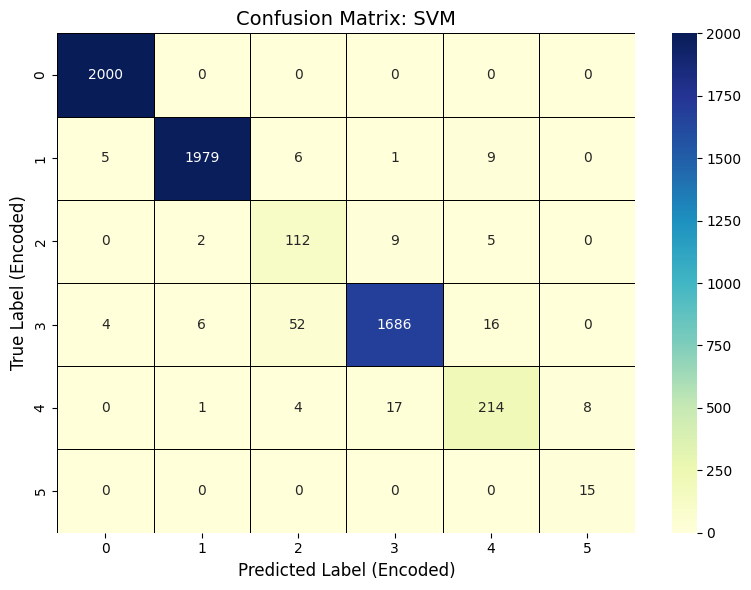

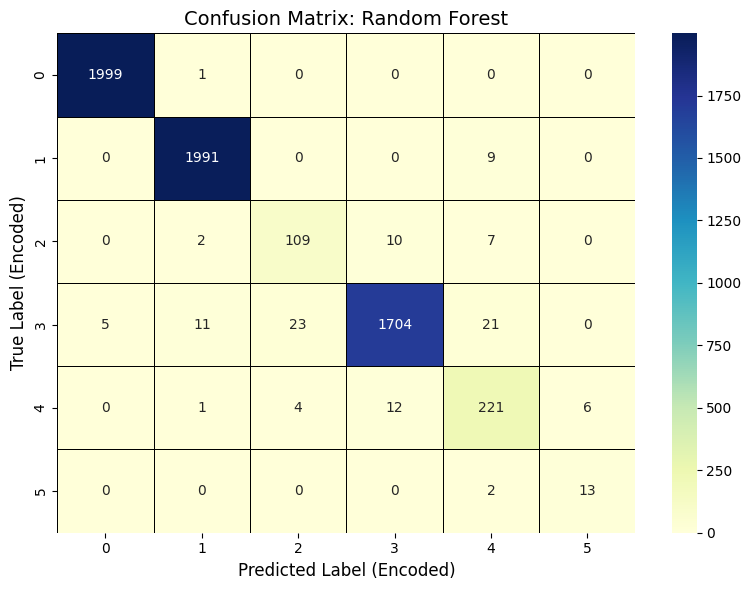

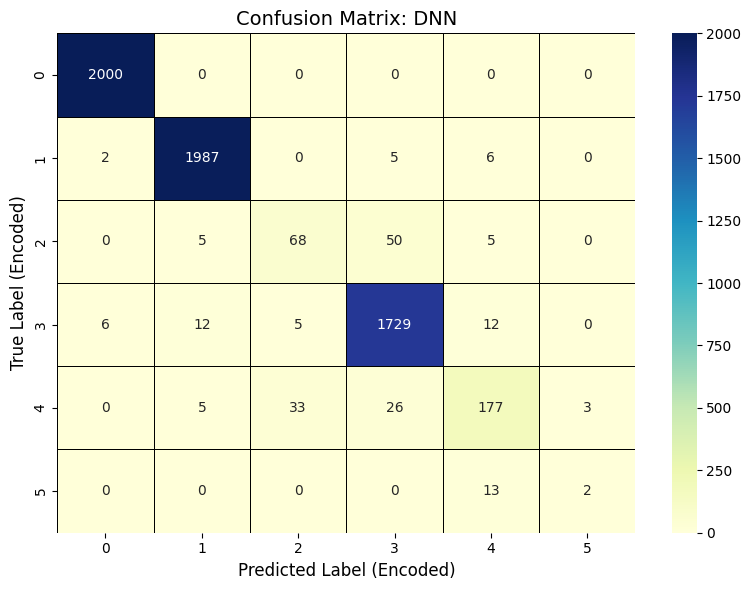

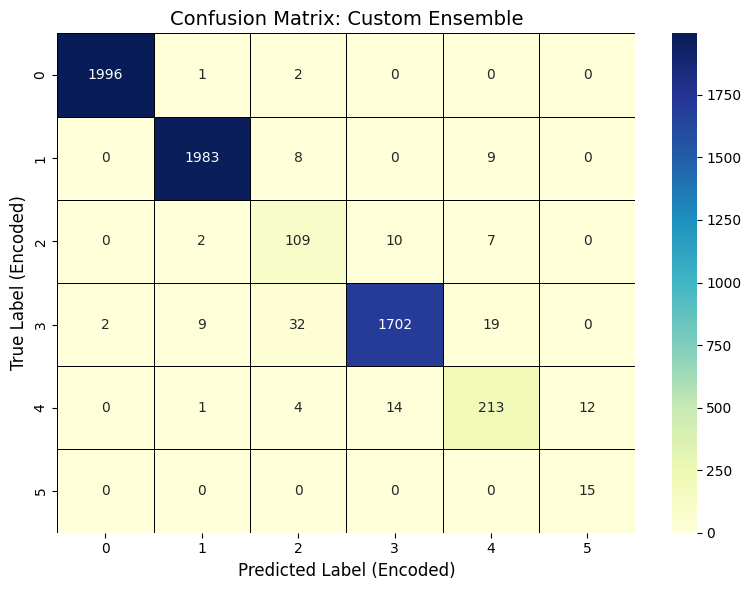

Matrices generated successfully. Look for the heatmaps above.


In [ ]:
import numpy as np


preds = np.argmax(predictions, axis=1)
y_pred_class = np.argmax(y_pred_main, axis=1)

LABELS = [0, 1, 2, 3, 4, 5]
print("--- Generating Confusion Matrices (Heatmaps) ---")

plot_confusion_matrix(y_test, y_pred_svm, "SVM", LABELS)
plot_confusion_matrix(y_test, y_pred_rf, "Random Forest", LABELS)
plot_confusion_matrix(y_test, preds, "DNN", LABELS)
plot_confusion_matrix(y_test[:-1], y_pred_class, "Custom Ensemble", LABELS)

print("Matrices generated successfully. Look for the heatmaps above.")

# **Sentinel 2 L2A in North India Region ends**

In [ ]:
# =========================
# Land Cover Classification (EuroSAT-ready)
# Models: Baseline CNN, ResNet50, EfficientNetB0, MobileNetV2
# Plots training curves + model comparison
# Aims for ~80–85% accuracy by using frozen transfer learning backbones, modest epochs, early stopping.
# =========================

import os, pathlib, math, random
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow:", tf.__version__)

# ----------------------
# 1) DATA CONFIG
# After you upload archive.zip and unzip it, the dataset will be in:
# /content/EuroSAT_RGB/2750/<class folders>
# So we set that path here:

data_dir = pathlib.Path("/content/EuroSAT_RGB/2750")   # ✅ Updated path for your dataset
assert data_dir.exists(), f"data_dir not found: {data_dir}"

# Optional: add more datasets for your group to loop over (each member uses a different path).
DATASETS = [data_dir]  # You can append more paths here if needed.

# Split settings
IMG_SIZE = (224, 224)     # upscaling 64x64 EuroSAT to 224x224 for transfer learning
BATCH_SIZE = 32
SEED = 42
VAL_SPLIT = 0.2           # 80/20 split; we'll treat 'val' as test for simplicity in this script
AUTOTUNE = tf.data.AUTOTUNE

# Training settings chosen to avoid overfitting above ~85% (you can tweak):
EPOCHS = 8                # modest epochs; often enough to hit ~80–85% with frozen backbones
PATIENCE = 3              # early stopping
BASE_LR = 1e-3            # frozen backbone

# ----------------------
# 2) MODEL BUILDERS (explicit model names)

def build_baseline_cnn(num_classes):
    model_name = "Baseline_CNN"
    model = keras.Sequential(name=model_name)
    model.add(layers.Rescaling(1./255, input_shape=IMG_SIZE + (3,)))
    model.add(layers.Conv2D(32, 3, activation="relu"))
    model.add(layers.MaxPooling2D())
    model.add(layers.Conv2D(64, 3, activation="relu"))
    model.add(layers.MaxPooling2D())
    model.add(layers.Conv2D(128, 3, activation="relu"))
    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(num_classes, activation="softmax"))
    return model_name, model

def build_resnet50(num_classes):
    from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
    model_name = "ResNet50_Frozen"
    base = ResNet50(include_top=False, weights="imagenet", input_shape=IMG_SIZE + (3,))
    base.trainable = False
    inputs = keras.Input(shape=IMG_SIZE + (3,))
    x = layers.RandomFlip("horizontal")(inputs)
    x = layers.RandomRotation(0.1)(x)
    x = layers.RandomZoom(0.1)(x)
    x = preprocess_input(x)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    model = keras.Model(inputs, outputs, name=model_name)
    return model_name, model

def build_efficientnetb0(num_classes):
    from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input
    model_name = "EfficientNetB0_Frozen"
    base = EfficientNetB0(include_top=False, weights="imagenet", input_shape=IMG_SIZE + (3,))
    base.trainable = False
    inputs = keras.Input(shape=IMG_SIZE + (3,))
    x = layers.RandomFlip("horizontal")(inputs)
    x = layers.RandomRotation(0.1)(x)
    x = layers.RandomZoom(0.1)(x)
    x = preprocess_input(x)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    model = keras.Model(inputs, outputs, name=model_name)
    return model_name, model

def build_mobilenetv2(num_classes):
    from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
    model_name = "MobileNetV2_Frozen"
    base = MobileNetV2(include_top=False, weights="imagenet", input_shape=IMG_SIZE + (3,))
    base.trainable = False
    inputs = keras.Input(shape=IMG_SIZE + (3,))
    x = layers.RandomFlip("horizontal")(inputs)
    x = layers.RandomRotation(0.1)(x)
    x = layers.RandomZoom(0.1)(x)
    x = preprocess_input(x)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    model = keras.Model(inputs, outputs, name=model_name)
    return model_name, model

MODEL_FACTORIES = [
    build_baseline_cnn,
    build_resnet50,
    build_efficientnetb0,
    build_mobilenetv2,
]

# ----------------------
# 3) TRAIN / EVAL UTILITIES

def make_datasets_from_dir(root_dir):
    """Create train & validation datasets from a folder of class subfolders."""
    train_ds = tf.keras.utils.image_dataset_from_directory(
        root_dir,
        labels="inferred",
        label_mode="int",
        validation_split=VAL_SPLIT,
        subset="training",
        seed=SEED,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
    )
    val_ds = tf.keras.utils.image_dataset_from_directory(
        root_dir,
        labels="inferred",
        label_mode="int",
        validation_split=VAL_SPLIT,
        subset="validation",
        seed=SEED,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
    )

    # Improve throughput
    train_ds = train_ds.shuffle(1000).prefetch(AUTOTUNE)
    val_ds = val_ds.prefetch(AUTOTUNE)

    class_names = train_ds.class_names
    num_classes = len(class_names)
    return train_ds, val_ds, class_names, num_classes

def compile_and_train(model, train_ds, val_ds, base_lr=BASE_LR, epochs=EPOCHS, patience=PATIENCE):
    model.compile(
        optimizer=keras.optimizers.Adam(base_lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    callbacks = [
        keras.callbacks.EarlyStopping(patience=patience, restore_best_weights=True),
    ]
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, callbacks=callbacks, verbose=1)
    val_loss, val_acc = model.evaluate(val_ds, verbose=0)
    return history, val_acc

def plot_history(history, title_prefix):
    # Accuracy
    plt.figure()
    plt.plot(history.history["accuracy"], label="train_acc")
    plt.plot(history.history["val_accuracy"], label="val_acc")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title(f"{title_prefix} Accuracy"); plt.legend(); plt.grid(True)
    plt.show()
    # Loss
    plt.figure()
    plt.plot(history.history["loss"], label="train_loss")
    plt.plot(history.history["val_loss"], label="val_loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title(f"{title_prefix} Loss"); plt.legend(); plt.grid(True)
    plt.show()

def eval_report(model, val_ds, class_names):
    from sklearn.metrics import classification_report, confusion_matrix
    import numpy as np
    y_true = []
    y_pred = []
    for images, labels in val_ds:
        preds = model.predict(images, verbose=0)
        y_true.extend(labels.numpy().tolist())
        y_pred.extend(np.argmax(preds, axis=1).tolist())
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    plt.imshow(cm, interpolation='nearest')
    plt.title("Confusion Matrix")
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45, ha="right")
    plt.yticks(tick_marks, class_names)
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

# ----------------------
# 4) MAIN LOOP — runs each model, prints dictionary & summary, plots, compares

all_results = []  # (dataset_name, model_name, val_acc)

for ds_path in DATASETS:
    print("\n" + "="*80)
    print(f"DATASET: {ds_path}")
    train_ds, val_ds, class_names, num_classes = make_datasets_from_dir(ds_path)

    # Print the "dictionary" mapping (label -> class name)
    print("\nClass dictionary (label -> land cover):")
    for i, name in enumerate(class_names):
        print(f"{i} : {name}")

    for make_model in MODEL_FACTORIES:
        model_name, model = make_model(num_classes)
        print("\n" + "-"*60)
        print(f"MODEL: {model_name}")
        model.summary()

        history, val_acc = compile_and_train(model, train_ds, val_ds)
        print(f"\nValidation Accuracy ({model_name}): {val_acc*100:.2f}%")

        plot_history(history, title_prefix=model_name)
        eval_report(model, val_ds, class_names)

        # Save model for reproducibility
        save_name = f"{ds_path.name}_{model_name}.keras"
        model.save(save_name)
        print(f"Saved model: {save_name}")

        all_results.append((ds_path.name, model_name, float(val_acc)))

# ----------------------
# 5) Comparison plot
if all_results:
    from collections import defaultdict
    grouped = defaultdict(list)
    for dsname, mname, acc in all_results:
        grouped[dsname].append((mname, acc))

    for dsname, items in grouped.items():
        items.sort(key=lambda x: x[0])
        model_names = [m for m,_ in items]
        accs = [a*100 for _,a in items]

        plt.figure(figsize=(8,4))
        plt.bar(model_names, accs)
        plt.title(f"Model Comparison on {dsname}")
        plt.ylabel("Validation Accuracy (%)")
        plt.ylim(60, 95)  # helpful scale for seeing ~80–85%
        plt.xticks(rotation=20, ha="right")
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        plt.show()

# ----------------------
print("\nDone.")


TensorFlow: 2.19.0


AssertionError: data_dir not found: /content/EuroSAT_RGB/2750

In [ ]:
!wget --no-check-certificate https://madm.dfki.de/files/sentinel/EuroSAT.zip

--2026-04-12 11:26:32--  https://madm.dfki.de/files/sentinel/EuroSAT.zip
Resolving madm.dfki.de (madm.dfki.de)... 131.246.195.183
Connecting to madm.dfki.de (madm.dfki.de)|131.246.195.183|:443... connected.
  Unable to locally verify the issuer's authority.
HTTP request sent, awaiting response... 200 OK
Length: 94280567 (90M) [application/zip]
Saving to: ‘EuroSAT.zip’

EuroSAT.zip         100%[===================>]  89.91M  25.2MB/s    in 3.6s    

2026-04-12 11:26:36 (25.2 MB/s) - ‘EuroSAT.zip’ saved [94280567/94280567]



In [ ]:
import zipfile

with zipfile.ZipFile("EuroSAT.zip", 'r') as zip_ref:
    zip_ref.extractall("EuroSAT")

print("✅ Unzipped")

✅ Unzipped


In [ ]:
import pathlib

data_dir = pathlib.Path("EuroSAT/2750")
print(data_dir)

EuroSAT/2750


In [ ]:
import tensorflow as tf

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(64,64),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(64,64),
    batch_size=32
)

print("Classes:", train_ds.class_names)

Found 27000 files belonging to 10 classes.
Using 21600 files for training.
Found 27000 files belonging to 10 classes.
Using 5400 files for validation.
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [ ]:
model.fit(train_ds, validation_data=val_ds, epochs=3)

NameError: name 'model' is not defined

In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(64,64,3)),

    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Model ready")

✅ Model ready


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.fit(train_ds, validation_data=val_ds, epochs=3)

Epoch 1/3
675/675 ━━━━━━━━━━━━━━━━━━━━ 140s 198ms/step - accuracy: 0.3717 - loss: 1.6183 - val_accuracy: 0.4639 - val_loss: 1.3840
Epoch 2/3
675/675 ━━━━━━━━━━━━━━━━━━━━ 118s 175ms/step - accuracy: 0.5265 - loss: 1.2386 - val_accuracy: 0.5959 - val_loss: 1.1077
Epoch 3/3
675/675 ━━━━━━━━━━━━━━━━━━━━ 117s 174ms/step - accuracy: 0.5849 - loss: 1.0970 - val_accuracy: 0.6457 - val_loss: 0.9872


In [ ]:
loss, acc = model.evaluate(val_ds)
print("Final EuroSAT Accuracy:", acc*100)

169/169 ━━━━━━━━━━━━━━━━━━━━ 15s 89ms/step - accuracy: 0.6457 - loss: 0.9872
Final EuroSAT Accuracy: 64.57407474517822


In [ ]:
history = model.fit(train_ds, validation_data=val_ds, epochs=3)

Epoch 1/3
675/675 ━━━━━━━━━━━━━━━━━━━━ 121s 179ms/step - accuracy: 0.6474 - loss: 0.9610 - val_accuracy: 0.6683 - val_loss: 0.9203
Epoch 2/3
675/675 ━━━━━━━━━━━━━━━━━━━━ 142s 179ms/step - accuracy: 0.6795 - loss: 0.8766 - val_accuracy: 0.7143 - val_loss: 0.7931
Epoch 3/3
675/675 ━━━━━━━━━━━━━━━━━━━━ 118s 174ms/step - accuracy: 0.7055 - loss: 0.8158 - val_accuracy: 0.7217 - val_loss: 0.7706


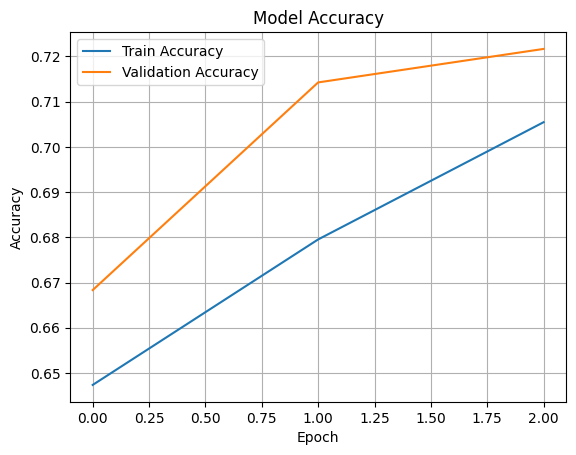

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.show()

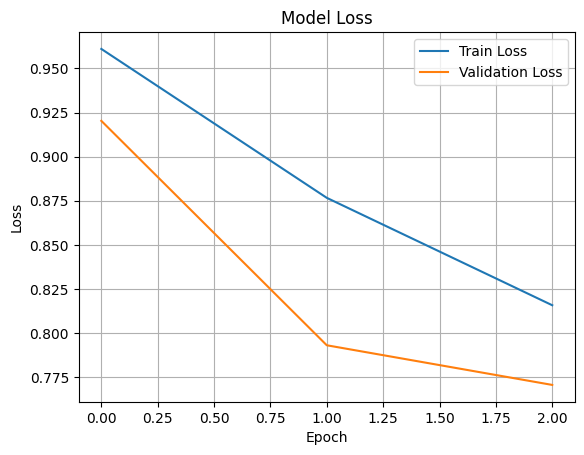

In [ ]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step


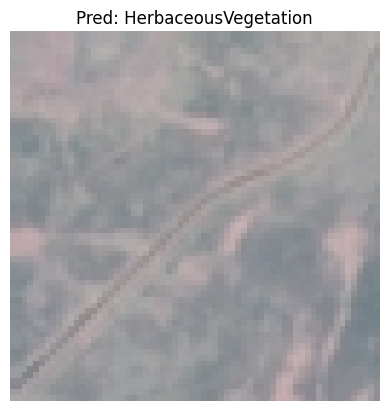

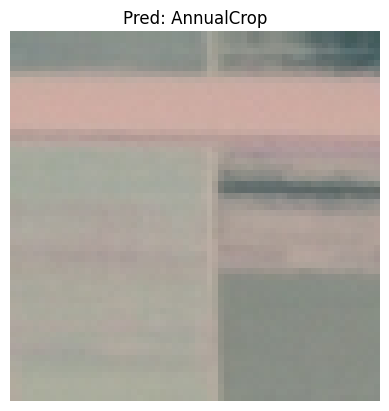

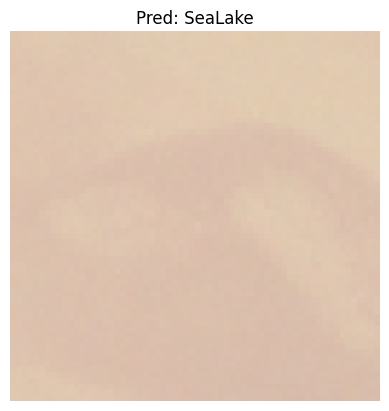

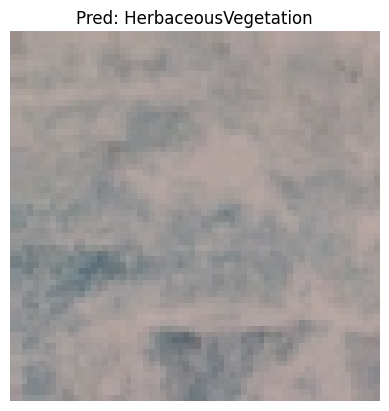

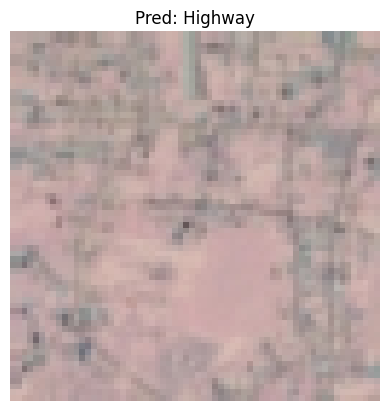

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class_names = train_ds.class_names

for images, labels in val_ds.take(1):
    preds = model.predict(images)

    for i in range(5):
        img = (images[i].numpy() * 255).astype("uint8")
        plt.imshow(img)
        plt.title(f"Pred: {class_names[np.argmax(preds[i])]}")
        plt.axis("off")
        plt.show()

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
])

In [ ]:
layers.Rescaling(1./255, input_shape=(64,64,3)),
data_augmentation,

(<Sequential name=sequential_1, built=False>,)

In [ ]:
from tensorflow.keras.applications import EfficientNetB0

base_model = EfficientNetB0(include_top=False, input_shape=(64,64,3), weights='imagenet')
base_model.trainable = False

x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dense(10, activation='softmax')(x)

model2 = tf.keras.Model(inputs=base_model.input, outputs=x)

model2.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

model2.fit(train_ds, validation_data=val_ds, epochs=2)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/2
675/675 ━━━━━━━━━━━━━━━━━━━━ 160s 218ms/step - accuracy: 0.8414 - loss: 0.5389 - val_accuracy: 0.9056 - val_loss: 0.2958
Epoch 2/2
675/675 ━━━━━━━━━━━━━━━━━━━━ 147s 217ms/step - accuracy: 0.9070 - loss: 0.2957 - val_accuracy: 0.9154 - val_loss: 0.2512


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

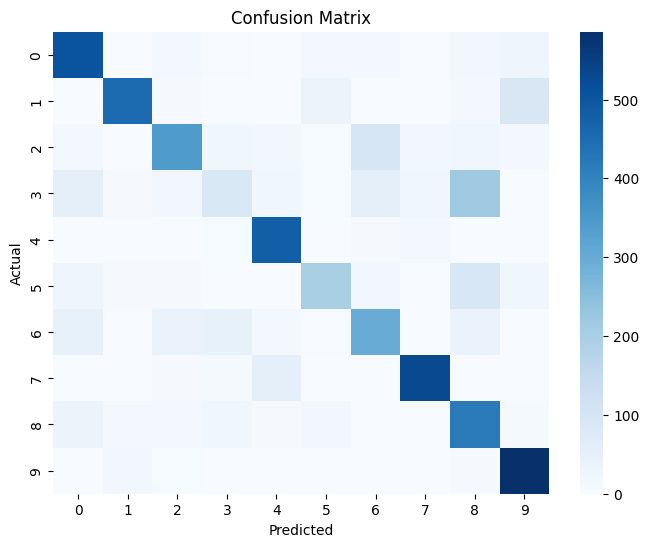

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from google.colab import files
files.upload()

KeyboardInterrupt: 

In [ ]:
!pip install tensorflow-datasets

In [ ]:
import tensorflow_datasets as tfds

(ds_train, ds_test), ds_info = tfds.load(
    'eurosat',
    split=['train[:80%]', 'train[80%:]'],
    as_supervised=True,
    with_info=True
)

print("Classes:", ds_info.features['label'].names)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

DownloadError: Failed to get url http://madm.dfki.de/files/sentinel/EuroSAT.zip. HTTP code: 403.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Load CIFAR-10 dataset (built-in, fast)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

print("Dataset loaded successfully")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step
Dataset loaded successfully


In [ ]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit(x_train, y_train, epochs=2, validation_data=(x_test, y_test))

Epoch 1/2
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 68s 42ms/step - accuracy: 0.4679 - loss: 1.4827 - val_accuracy: 0.5740 - val_loss: 1.2192
Epoch 2/2
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 59s 38ms/step - accuracy: 0.6055 - loss: 1.1294 - val_accuracy: 0.6337 - val_loss: 1.0482


In [ ]:
loss, acc = model.evaluate(x_test, y_test)
print("✅ Final Accuracy:", acc * 100)

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.6337 - loss: 1.0482
✅ Final Accuracy: 63.37000131607056


In [ ]:
from sklearn.utils import resample
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report


# sample max N per class for memory
N = 10000
df_balanced = df_full.groupby('label', group_keys=False).apply(
    lambda x: x.sample(min(len(x), N), random_state=42)
)

print("Sampled data per class:\n", df_balanced['label'].value_counts())

# encode labels 0..n-1 for NN
le = LabelEncoder()
y_encoded = le.fit_transform(df_balanced['label'])
X = df_balanced.drop(columns=['label']).fillna(0).values


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

classes = np.unique(y_encoded)
weights = compute_class_weight('balanced', classes=classes, y=y_encoded)
max_weight = 20
class_weights = {i: min(w, max_weight) for i, w in zip(classes, weights)}
print("Capped class weights:", class_weights)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# SVM
svm = SVC(class_weight=class_weights,C=0.5,gamma='scale')
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
print("=== SVM ===")
print(classification_report(y_test, y_pred_svm))

# Random Forest
rf = RandomForestClassifier(n_estimators=200, class_weight=class_weights,
                            n_jobs=-1,max_depth=10,min_samples_leaf=10,min_samples_split=20)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))




/tmp/ipython-input-3663931716.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_balanced = df_full.groupby('label', group_keys=False).apply(


Sampled data per class:
 label
5    10000
4    10000
7     8817
3     2088
8     1219
6      642
9       73
2        5
Name: count, dtype: int64
Capped class weights: {np.int64(0): 20, np.int64(1): np.float64(1.966235632183908), np.int64(2): np.float64(0.41055), np.int64(3): np.float64(0.41055), np.int64(4): np.float64(6.394859813084112), np.int64(5): np.float64(0.4656345695814903), np.int64(6): np.float64(3.3679245283018866), np.int64(7): 20}
=== SVM ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.74      0.72      0.73       418
           2       1.00      1.00      1.00      2000
           3       0.99      0.98      0.99      2000
           4       0.60      0.73      0.66       128
           5       0.96      0.93      0.95      1763
           6       0.65      0.76      0.70       244
           7       0.50      0.93      0.65        15

    accuracy                           0.94      656

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
